# Análisis de variables — velocidad de arriendo

Este notebook **no entrena ningún modelo**. Su único trabajo es dejar claro cómo se comportan
las variables antes de decidir qué modelar. Se ejecuta de arriba hacia abajo sobre
`query_analisis.sql`, que es la única query del proyecto.

**Orden de lectura, y por qué ese orden:**

| Paso | Qué responde | Por qué va antes que lo siguiente |
|---|---|---|
| 0 · Inventario | ¿Cuánta muestra sobrevive, y se parece a la que se cae? | Si lo descartado tiene otro desenlace, todo lo demás está condicionado |
| 1 · Grano y consistencia | ¿Una fila por unidad? ¿La censura es coherente? | Un duplicado silencioso invalida cualquier promedio |
| 2 · El outcome | ¿`days_to_event` mide duración de mercado o está censurado? | Define qué target es honesto |
| 3 · Univariado | ¿Qué hay en cada variable: rango, faltantes, colas? | Evita interpretar un efecto que es un outlier |
| 4 · Bivariado | ¿Cada variable mueve la velocidad, y en qué forma? | Es el insumo de la selección de features |
| 5 · Precio | ¿El sobreprecio demora, o mata? | Es la pregunta comercial del proyecto |
| 6 · Demanda | ¿Cómo se ve el embudo visitas → leads → reservas? | Y qué parte de él es usable ex-ante |
| 7 · Deriva temporal | ¿Las cohortes son comparables entre sí? | Determina cómo se parte train/test |
| 8 · Colinealidad | ¿Qué variables son la misma variable? | Evita leer dos veces el mismo efecto |

**Una convención que hay que respetar al leer.** Las columnas con prefijo `no_modelo_` miran
hacia adelante desde `fecha_LPA`: son el target o son descripción del desenlace. Aparecen en
todo el notebook porque son justamente lo que queremos entender, pero **ninguna puede entrar
como feature** de un score que se calcula el día 0. Las columnas `d0_7_` son la excepción
parcial: ya ocurrieron al día 7, así que sirven para predecir los días 8 en adelante, pero
solo dentro de la submuestra que llegó viva al día 7.

## Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import warnings
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
warnings.filterwarnings("ignore", category=FutureWarning)

# --- Paleta -----------------------------------------------------------------
# La misma de diagnostico_gap_ml.ipynb, a proposito: dos notebooks del mismo
# proyecto que usan colores distintos se leen como dos analisis distintos.
# Un scatter no soporta mas de 3 hues categoricos distinguibles, asi que las
# figuras usan una serie por panel y facetan en vez de colorear.
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"
GRID, SURFACE = "#e6e4dd", "#fcfcfb"
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 9, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})

# --- Parametros del analisis ------------------------------------------------
# De negocio, no estadisticos. Un arriendo bajo 150k o sobre 2,5M en estos
# sectores es un error de dato, no un outlier legitimo.
PRECIO_MIN, PRECIO_MAX = 150_000, 2_500_000

# Horizontes del target binario. El proyecto define 20 dias; los otros dos
# estan para ver si la conclusion depende del corte elegido.
HORIZONTES = [15, 20, 30]

# |log ratio| <= 0,50  ->  banda de -39% a +65% contra la recomendacion del ML
GAP_MAX   = 0.50
N_SEG_MIN = 5      # celdas comuna x tipologia x mes mas chicas no se leen
MIN_OBS   = 30     # categorias con menos observaciones se agrupan en "Otras"

## Carga

Una sola query. El patrón del proyecto: `load_sql_query` + `Engine` + `.env`, forzando
`pymysql` en vez de `mysqlconnector` porque el conector oficial rompe con los tipos `DATE`
cero que la base todavía usa como "sin fecha".

Lo que hizo posible volver a una sola sentencia fue el filtro `created >= 2025-07-01`. Como
toda ventana empieza después de esa fecha, las tres tablas de eventos se pueden podar por
fecha **antes** de cualquier join — y eso es lo que salva a `bi_DimLeadAttemps`, que tiene
1,2 millones de filas y cuyo único índice es `idx_created_at`. La query trae 82 columnas; el
archivo `query_analisis_final.sql` documenta arriba las tres reglas que la mantienen rápida.

In [2]:
import sqlalchemy
from sqlalchemy import text
from dotenv import load_dotenv
from utils import load_sql_query, Engine, logger

load_dotenv()
username = os.getenv("DATABASE_USERNAME")
password = quote_plus(os.getenv("DATABASE_PASSWORD"))
host     = os.getenv("DATABASE_HOST")
database = os.getenv("DATABASE_NAME")

engine = Engine()
engine.engine = sqlalchemy.create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{database}",
    pool_recycle=300,
    pool_pre_ping=True,
)

import time

t0 = time.time()
df = pd.read_sql(text(load_sql_query("query_analisis_final.sql")), engine.engine)
print(f"{time.time() - t0:.1f}s · {len(df):,} filas · "
      f"{df['property_id'].nunique():,} properties · {df.shape[1]} columnas")

assert df["property_id"].is_unique, "property_id no es unico: hay un join que duplica"
df.head(3)

18.8s · 7,683 filas · 7,683 properties · 93 columnas


,property_id,unit_id,owner_id,grupo_edificio,comuna,barrio,sector_provincia,nombre_tipologia,dormitorios,banos,estudio,m2_utiles,m2_por_dormitorio,piso,acepta_mascotas,first_time_rented,ha_sido_arrendada,owner_type,ggcc,precio_lpa,precio_post,n_registros_precio_previos,fecha_LPA,fecha_creacion,dias_habilitacion,cohorte_lpa,mes_lpa,year_lpa,trimestre_lpa,dow_lpa,d0_7_visitas,d0_7_leads,d0_7_reservas,sobrevive_d7,no_modelo_days_to_event,no_modelo_dias_observados,no_modelo_censurada,no_modelo_tipo_evento,no_modelo_churn,no_modelo_fecha_check_in,...,no_modelo_monto_arriendo,no_modelo_renter_id,no_modelo_actual_activa,no_modelo_dias_contrato_a_baja,no_modelo_visitas_sem_1,no_modelo_visitas_sem_2,no_modelo_visitas_sem_3,no_modelo_visitas_sem_4,no_modelo_visitas_sem5_a_90,no_modelo_visitas_90d,no_modelo_dias_con_observacion,no_modelo_first_visit_obs,no_modelo_last_visit_obs,no_modelo_leads_90d,no_modelo_reservas_90d,flag_sin_datos_visitas,no_modelo_precio_cierre,no_modelo_n_precios_ventana,precio_ml_expost,precio_ml_actual,ml_pricing_date,uf_m2,flag_ml_es_ex_ante,heredado,tipologia_origen,origen_dormitorios,origen_banos,flag_discrepancia_tipologia,flag_evento_previo_lpa,precio_oferta,flag_precio_posterior_al_lpa,precio_m2,no_modelo_pct_bajada,no_modelo_ratio_cierre_vs_oferta,no_modelo_precio_plano,ratio_ml,log_ratio_ml,motivo_exclusion,n_segmento,log_ratio_centrado
0,513901,187_704-C_3,13752,Jardines de Olivares,Santiago,Bulnes,Santiago - Centro,1D1B,1.000,1.000,0,34.000,34.000,0.000,1,0000-00-00 00:00:00,No,new,"50,000.000",NaN,NaN,0,NaT,2025-07-01,NaN,None,NaN,NaN,NaN,NaN,0.000,0,0,0,NaN,NaN,0,churn,1,NaT,...,None,NaN,0,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0,None,None,0,0,1,NaN,0,NaN,NaN,None,NaN,0,NaN,D y B,pricing,pricing,0,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,sin fecha LPA,0,NaN
1,513904,2860_1602_3,13753,Santa Cristina,Macul,Punta De Rieles,Santiago - Suroriente,2D2B,2.000,2.000,0,50.000,25.000,0.000,1,0000-00-00 00:00:00,No,new,"95,000.000",NaN,NaN,0,NaT,2025-07-01,NaN,None,NaN,NaN,NaN,NaN,0.000,0,0,0,NaN,NaN,0,churn,1,NaT,...,None,NaN,0,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0,None,None,0,0,1,NaN,0,NaN,NaN,None,NaN,0,NaN,D y B,pricing,pricing,0,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,sin fecha LPA,0,NaN
2,513905,3476_101_3,13754,Güemes 10,La Reina,Lynch,Santiago - Nororiente,3D,3.000,1.000,0,70.000,23.300,0.000,1,0000-00-00 00:00:00,No,new,NaN,NaN,NaN,0,NaT,2025-07-01,NaN,None,NaN,NaN,NaN,NaN,0.000,0,0,1,NaN,NaN,1,sin evento,0,NaT,...,None,NaN,1,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0,None,None,0,0,1,NaN,0,"770,000.000",NaN,None,NaN,0,NaN,solo D,pricing,pricing,0,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,sin fecha LPA,0,NaN


In [3]:
# Tipos. La query devuelve varias columnas como object por venir de DECIMAL o
# de fechas cero; sin esto un describe() silencioso omite media y percentiles.
NUMERICAS_RAW = [
    "dormitorios", "banos", "estudio", "m2_utiles", "m2_por_dormitorio", "piso",
    "acepta_mascotas", "ggcc", "precio_oferta", "precio_lpa", "precio_post",
    "precio_m2",
    "dias_habilitacion", "d0_7_visitas", "d0_7_leads", "d0_7_reservas",
    "no_modelo_days_to_event", "no_modelo_days_to_check_in",
    "no_modelo_dias_contrato_a_check_in", "no_modelo_days_to_reserva",
    "no_modelo_dias_reserva_a_contrato", "no_modelo_days_to_contrato",
    "no_modelo_n_reservas_pre_contrato",
    "no_modelo_dias_observados", "no_modelo_censurada",
    "no_modelo_churn", "no_modelo_visitas_sem_1", "no_modelo_visitas_sem_2",
    "no_modelo_visitas_sem_3", "no_modelo_visitas_sem_4",
    "no_modelo_visitas_sem5_a_90", "no_modelo_visitas_90d",
    "no_modelo_leads_90d", "no_modelo_reservas_90d", "no_modelo_precio_cierre",
    "no_modelo_n_precios_ventana", "no_modelo_pct_bajada",
    "no_modelo_monto_arriendo", "precio_ml_expost", "uf_m2",
    "ratio_ml", "log_ratio_ml", "log_ratio_centrado", "n_segmento",
]
for c in NUMERICAS_RAW:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["fecha_LPA", "fecha_creacion", "no_modelo_event_date",
          "no_modelo_fecha_check_in", "no_modelo_fecha_primera_reserva",
          "no_modelo_fecha_ultima_reserva_pre_contrato",
          "no_modelo_inicio_contrato", "no_modelo_fecha_baja", "ml_pricing_date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

print(df.dtypes.value_counts().to_string())

float64           43
int64             23
object            18
datetime64[ns]     9


## Paso 0 · Inventario y peaje de exclusiones

La query no filtra nada: trae todas las unidades del universo y marca en `motivo_exclusion`
por qué cada una no es analizable. Esta tabla es la primera que hay que mirar y la que hay que
citar como limitación en cualquier informe.

Lo que se busca no es el conteo sino **la diferencia de desenlace entre lo que sobrevive y lo
que se cae**. Si las excluidas tienen otra tasa de churn o de censura, el análisis queda
condicionado en el éxito y las conclusiones sobre velocidad dejan de ser generalizables.

En el diagnóstico previo esto no era hipotético: las unidades *sin fecha LPA* eran ~20% de la
muestra y tenían **96% de churn**. Un `INNER JOIN` las borraba junto con el hallazgo.

In [4]:
inv = (df.groupby("motivo_exclusion")
         .agg(n              = ("property_id", "size"),
              churn          = ("no_modelo_churn", "mean"),
              censurada      = ("no_modelo_censurada", "mean"),
              dias_obs_p50   = ("no_modelo_dias_observados", "median"),
              dias_evento_p50= ("no_modelo_days_to_event", "median"),
              visitas_d0_7   = ("d0_7_visitas", "mean"),
              precio_p50     = ("precio_oferta", "median"))
         .sort_values("n", ascending=False))
inv["pct"] = inv["n"] / inv["n"].sum()
display(inv.round(3))

print(
    "Lectura:\n"
    "  'ventana invalida'      -> bug arreglable en la logica de heredado / event_date\n"
    "                             (el contrato se creo antes de que la unidad estuviera lista).\n"
    "  'sin historical_pricing'-> cobertura de datos. No se arregla con SQL: hay que declararlo.\n"
    "  'sin fecha LPA'         -> la unidad nunca se marco como lista. Si su churn es alto,\n"
    "                             es un problema de proceso, no de datos, y es un hallazgo."
)

,n,churn,censurada,dias_obs_p50,dias_evento_p50,visitas_d0_7,precio_p50,pct
motivo_exclusion,,,,,,,,
analizable,3862,0.182,0.191,40.000,37.000,8.396,"380,000.000",0.503
sin fecha LPA,3459,0.246,0.754,NaN,NaN,0.000,NaN,0.450
sin historical_pricing,279,0.559,0.237,65.000,64.000,0.573,NaN,0.036
contrato heredado,67,0.000,0.000,18.000,18.000,0.403,"337,000.000",0.009
ventana invalida,16,1.000,0.000,0.000,0.000,0.000,"410,000.000",0.002


Lectura:
  'ventana invalida'      -> bug arreglable en la logica de heredado / event_date
                             (el contrato se creo antes de que la unidad estuviera lista).
  'sin historical_pricing'-> cobertura de datos. No se arregla con SQL: hay que declararlo.
  'sin fecha LPA'         -> la unidad nunca se marco como lista. Si su churn es alto,
                             es un problema de proceso, no de datos, y es un hallazgo.


In [5]:
# Muestra analizable + banda de precio de negocio.
# El filtro de banda se aplica DESPUES y se cuenta aparte, para no mezclar
# "no tengo el dato" con "el dato es imposible".
d = df[df["motivo_exclusion"] == "analizable"].copy()

fuera_banda = ~d["precio_oferta"].between(PRECIO_MIN, PRECIO_MAX)
print(f"Analizables por la query      : {len(d):,}")
print(f"Precio fuera de [{PRECIO_MIN:,}, {PRECIO_MAX:,}]: {int(fuera_banda.sum()):,} "
      f"({fuera_banda.mean():.1%})  |  churn de esas: {d.loc[fuera_banda,'no_modelo_churn'].mean():.3f}")

d = d[~fuera_banda].copy()
print(f"Muestra de trabajo            : {len(d):,}")

comp = pd.DataFrame({
    "grupo": ["universo completo", "descartadas", "muestra de trabajo"],
    "n":     [len(df), len(df) - len(d), len(d)],
    "churn": [df["no_modelo_churn"].mean(),
              df.loc[~df["property_id"].isin(d["property_id"]), "no_modelo_churn"].mean(),
              d["no_modelo_churn"].mean()],
    "censurada": [df["no_modelo_censurada"].mean(),
                  df.loc[~df["property_id"].isin(d["property_id"]), "no_modelo_censurada"].mean(),
                  d["no_modelo_censurada"].mean()],
    "dias_obs_p50": [df["no_modelo_dias_observados"].median(),
                     df.loc[~df["property_id"].isin(d["property_id"]), "no_modelo_dias_observados"].median(),
                     d["no_modelo_dias_observados"].median()],
})
display(comp.round(3))

Analizables por la query      : 3,862
Precio fuera de [150,000, 2,500,000]: 28 (0.7%)  |  churn de esas: 0.214
Muestra de trabajo            : 3,834


,grupo,n,churn,censurada,dias_obs_p50
0,universo completo,7683,0.225,0.444,41.000
1,descartadas,3849,0.267,0.696,60.000
2,muestra de trabajo,3834,0.182,0.191,40.000


In [6]:
# Targets binarios derivados de la duracion censurada.
#
# El punto delicado: una unidad censurada a los 8 dias NO es un 0 a 20 dias, es
# un dato desconocido. Marcarla 0 mete un sesgo hacia "lento" en las cohortes
# recientes, que son justamente las que menos tiempo llevan observadas.
# Por eso cada horizonte trae su propio NaN.
# QUE FECHA CUENTA COMO "SE ARRENDO". Una linea, y cambia todo el analisis.
#   no_modelo_days_to_event    -> creacion del contrato. Incluye la demora
#                                 administrativa entre el check-in y el papeleo.
#   no_modelo_days_to_check_in -> entrada a "Esperando Check-In". Es el cierre
#                                 comercial: la unidad ya salio del mercado.
# La celda de mas abajo mide la diferencia entre las dos antes de que elijas.
COL_DURACION = "no_modelo_days_to_event"

for h in HORIZONTES:
    arrendo_antes = (
        (d["no_modelo_tipo_evento"] == "arriendo")
        & (d[COL_DURACION] <= h)
        & (d[COL_DURACION] >= 0)
    )
    # Observable si ya paso el horizonte, o si el evento (cualquiera) ocurrio antes.
    observable = (d["no_modelo_dias_observados"] >= h) | (d[COL_DURACION] <= h)
    d[f"y_{h}"] = np.where(observable, arrendo_antes.astype(float), np.nan)

resumen_y = pd.DataFrame({
    f"y_{h}": {
        "n_observable": int(d[f"y_{h}"].notna().sum()),
        "pct_observable": d[f"y_{h}"].notna().mean(),
        "tasa_base": d[f"y_{h}"].mean(),
    } for h in HORIZONTES
}).T
display(resumen_y.round(3))
print("tasa_base = P(arrienda <= h dias) sobre las filas donde el desenlace a h dias ya se sabe.")

,n_observable,pct_observable,tasa_base
y_15,"3,727.000",0.972,0.205
y_20,"3,680.000",0.960,0.257
y_30,"3,621.000",0.944,0.346


tasa_base = P(arrienda <= h dias) sobre las filas donde el desenlace a h dias ya se sabe.


## Paso 1 · Grano y consistencia

Cinco afirmaciones que la query debería garantizar. Si alguna falla, no tiene sentido seguir:
un duplicado por join infla los conteos y sesga cualquier promedio hacia las unidades
duplicadas, que nunca son una muestra aleatoria.

In [7]:
checks = []

checks.append(("una fila por property_id",
               len(df) == df["property_id"].nunique(),
               f"{len(df):,} filas vs {df['property_id'].nunique():,} properties"))

incons = df[(df["no_modelo_tipo_evento"] == "sin evento") != (df["no_modelo_censurada"] == 1)]
checks.append(("'sin evento' <=> censurada = 1", len(incons) == 0, f"{len(incons):,} inconsistentes"))

incons2 = df[(df["no_modelo_censurada"] == 1) & df["no_modelo_days_to_event"].notna()]
checks.append(("censurada = 1 => days_to_event nulo", len(incons2) == 0, f"{len(incons2):,} inconsistentes"))

neg = int(df["flag_evento_previo_lpa"].sum())
checks.append(("sin eventos previos al LPA", neg == 0, f"{neg:,} filas con evento antes del LPA"))

disc = int(df["flag_discrepancia_tipologia"].sum())
checks.append(("tipologia coherente entre fuentes", disc == 0, f"{disc:,} discrepancias"))

res = pd.DataFrame(checks, columns=["check", "ok", "detalle"])
res["ok"] = res["ok"].map({True: "OK", False: "REVISAR"})
display(res)

,check,ok,detalle
0,una fila por property_id,OK,"7,683 filas vs 7,683 properties"
1,'sin evento' <=> censurada = 1,OK,0 inconsistentes
2,censurada = 1 => days_to_event nulo,OK,0 inconsistentes
3,sin eventos previos al LPA,REVISAR,16 filas con evento antes del LPA
4,tipologia coherente entre fuentes,OK,0 discrepancias


In [8]:
# Cobertura ex-ante del ML y dispersion del gap.
# Si flag_ml_es_ex_ante es casi siempre 0, aa_pmPricingExplainabilityPredictions
# es un snapshot que se sobreescribe: no hay backtest posible del modelo de
# pricing, solo un analisis de concordancia. Hay que presentarlo asi.
print("Cobertura ex-ante del ML:")
print(df["flag_ml_es_ex_ante"].value_counts(normalize=True).round(4).to_string())

print("\nDispersion del gap contra el ML (sobre la muestra de trabajo):")
print(f"  sd(log_ratio_ml)       = {d['log_ratio_ml'].std():.4f}")
print(f"  sd(log_ratio_centrado) = {d['log_ratio_centrado'].std():.4f}")
print(
    "\nSi sd(log_ratio_ml) < 0,05 el ML aprendio la politica de precios de la casa,\n"
    "no el mercado: no hay varianza real que correlacionar con la velocidad, y el\n"
    "problema esta en el target de entrenamiento del modelo de pricing."
)

print("\nOrigen de los atributos de tipologia:")
display(df.groupby(["origen_dormitorios", "origen_banos"]).size().rename("n").reset_index())

Cobertura ex-ante del ML:
flag_ml_es_ex_ante
0   0.961
1   0.039

Dispersion del gap contra el ML (sobre la muestra de trabajo):
  sd(log_ratio_ml)       = 0.1074
  sd(log_ratio_centrado) = 0.1708

Si sd(log_ratio_ml) < 0,05 el ML aprendio la politica de precios de la casa,
no el mercado: no hay varianza real que correlacionar con la velocidad, y el
problema esta en el target de entrenamiento del modelo de pricing.

Origen de los atributos de tipologia:


,origen_dormitorios,origen_banos,n
0,pricing,pricing,7644
1,sin dato,sin dato,39


## Paso 2 · El outcome: ¿`days_to_event` mide duración de mercado?

Tres cosas a buscar en estas figuras.

**Masa en la primera semana.** En una distribución de tiempo hasta evento, un pico en cero casi
siempre significa que la fecha de inicio se registra al final — que el movimiento a *Lista para
arrendar* se digita cuando ya hay contrato. Si eso pasa en una fracción grande, `days_to_event`
no mide lo que uno cree para esas filas, y ninguna feature va a explicarlas.

**Dónde termina la curva de supervivencia.** La curva se corta donde cortó la censura, no donde
se agotan las unidades. Por eso se grafica con las censuradas incluidas (Kaplan-Meier) y no
descartándolas.

**La diferencia entre los dos caminos.** Arriendo y churn son eventos distintos con signos
opuestos: el sobreprecio *alarga* el primero y *acorta* el segundo. Mezclados en una sola
variable de duración se cancelan y la correlación desaparece aunque el efecto exista.

### Qué fecha cuenta como "se arrendó"

**El cierre es la primera reserva.** Para una unidad que se arrendó, ahí es cuando deja el
mercado; el contrato se tramita después. `no_modelo_days_to_event` ya mide contra esa fecha,
así que el target y todo lo que cuelga de él cambiaron.

Dos cosas quedaron cableadas en la query y hay que vigilarlas, porque las dos pueden hacer
que la fecha sea la equivocada:

**No toda unidad arrendada tiene reserva registrada.** Cuando falta, `event_date` cae al
contrato. Eso mezcla dos definiciones dentro de la misma columna, y
`no_modelo_origen_event_date` dice cuál se usó en cada fila. Si el fallback es frecuente, la
mezcla es el problema, no el criterio.

**Una reserva puede caerse.** Si la unidad reservó el día 10, la reserva se cayó, volvió al
mercado y recién se arrendó el día 80, entonces la *primera* reserva no es el cierre —
estuvo disponible todo ese tiempo. `no_modelo_n_reservas_pre_contrato > 1` marca justo esos
casos. Para ellos la fecha correcta es `no_modelo_fecha_ultima_reserva_pre_contrato`, que
también sale de la query.

Antes de seguir hay que saber cuánto pesa cada una.

In [9]:
arr = d[d["no_modelo_tipo_evento"] == "arriendo"].copy()
print(f"Arrendadas analizables: {len(arr):,}\n")

print("Regla que definió event_date:")
mezcla = arr["no_modelo_origen_event_date"].value_counts(normalize=True).round(3)
display(mezcla.to_frame("proporcion"))
if mezcla.get("contrato", 0) > 0.2:
    print("  El fallback al contrato es frecuente: event_date NO es homogenea.\n"
          "  Reportar siempre la mezcla junto a cualquier metrica de velocidad.")

print("\nReservas caídas (más de una reserva antes del contrato):")
n_res = arr["no_modelo_n_reservas_pre_contrato"]
print(f"  0 reservas : {(n_res == 0).mean():>6.1%}   <- cae al contrato")
print(f"  1 reserva  : {(n_res == 1).mean():>6.1%}   <- caso limpio")
print(f"  2 o más    : {(n_res >= 2).mean():>6.1%}   <- la PRIMERA no es el cierre")

caidas = arr[n_res >= 2]
if len(caidas):
    brecha = (pd.to_datetime(caidas["no_modelo_fecha_ultima_reserva_pre_contrato"])
              - pd.to_datetime(caidas["no_modelo_fecha_primera_reserva"])).dt.days
    print(f"\n  En esas {len(caidas):,} filas, usar la última en vez de la primera")
    print(f"  atrasa el cierre en p50 {brecha.median():.0f} días (p90 {brecha.quantile(0.9):.0f}).")
    print("  Si eso mueve la tasa de colocación, cambiar fecha_primera_reserva por")
    print("  fecha_ultima_reserva_pre_contrato en el CASE de event_date de la query.")

Arrendadas analizables: 2,405

Regla que definió event_date:


,proporcion
no_modelo_origen_event_date,
reserva,0.771
contrato,0.229


  El fallback al contrato es frecuente: event_date NO es homogenea.
  Reportar siempre la mezcla junto a cualquier metrica de velocidad.

Reservas caídas (más de una reserva antes del contrato):
  0 reservas :  22.9%   <- cae al contrato
  1 reserva  :  71.1%   <- caso limpio
  2 o más    :   6.0%   <- la PRIMERA no es el cierre

  En esas 144 filas, usar la última en vez de la primera
  atrasa el cierre en p50 18 días (p90 67).
  Si eso mueve la tasa de colocación, cambiar fecha_primera_reserva por
  fecha_ultima_reserva_pre_contrato en el CASE de event_date de la query.


Días de tramitación (contrato − cierre), n = 2,405:
  p50 2 · p90 9 · máx 182

Mediana de días a cierre   : 29
Mediana de días a contrato : 34

  colocadas en <= 15d:  por contrato 25.2%  ·  por reserva 31.7%  ·  +6.5%
  colocadas en <= 20d:  por contrato 32.2%  ·  por reserva 39.3%  ·  +7.1%
  colocadas en <= 30d:  por contrato 45.9%  ·  por reserva 52.1%  ·  +6.2%


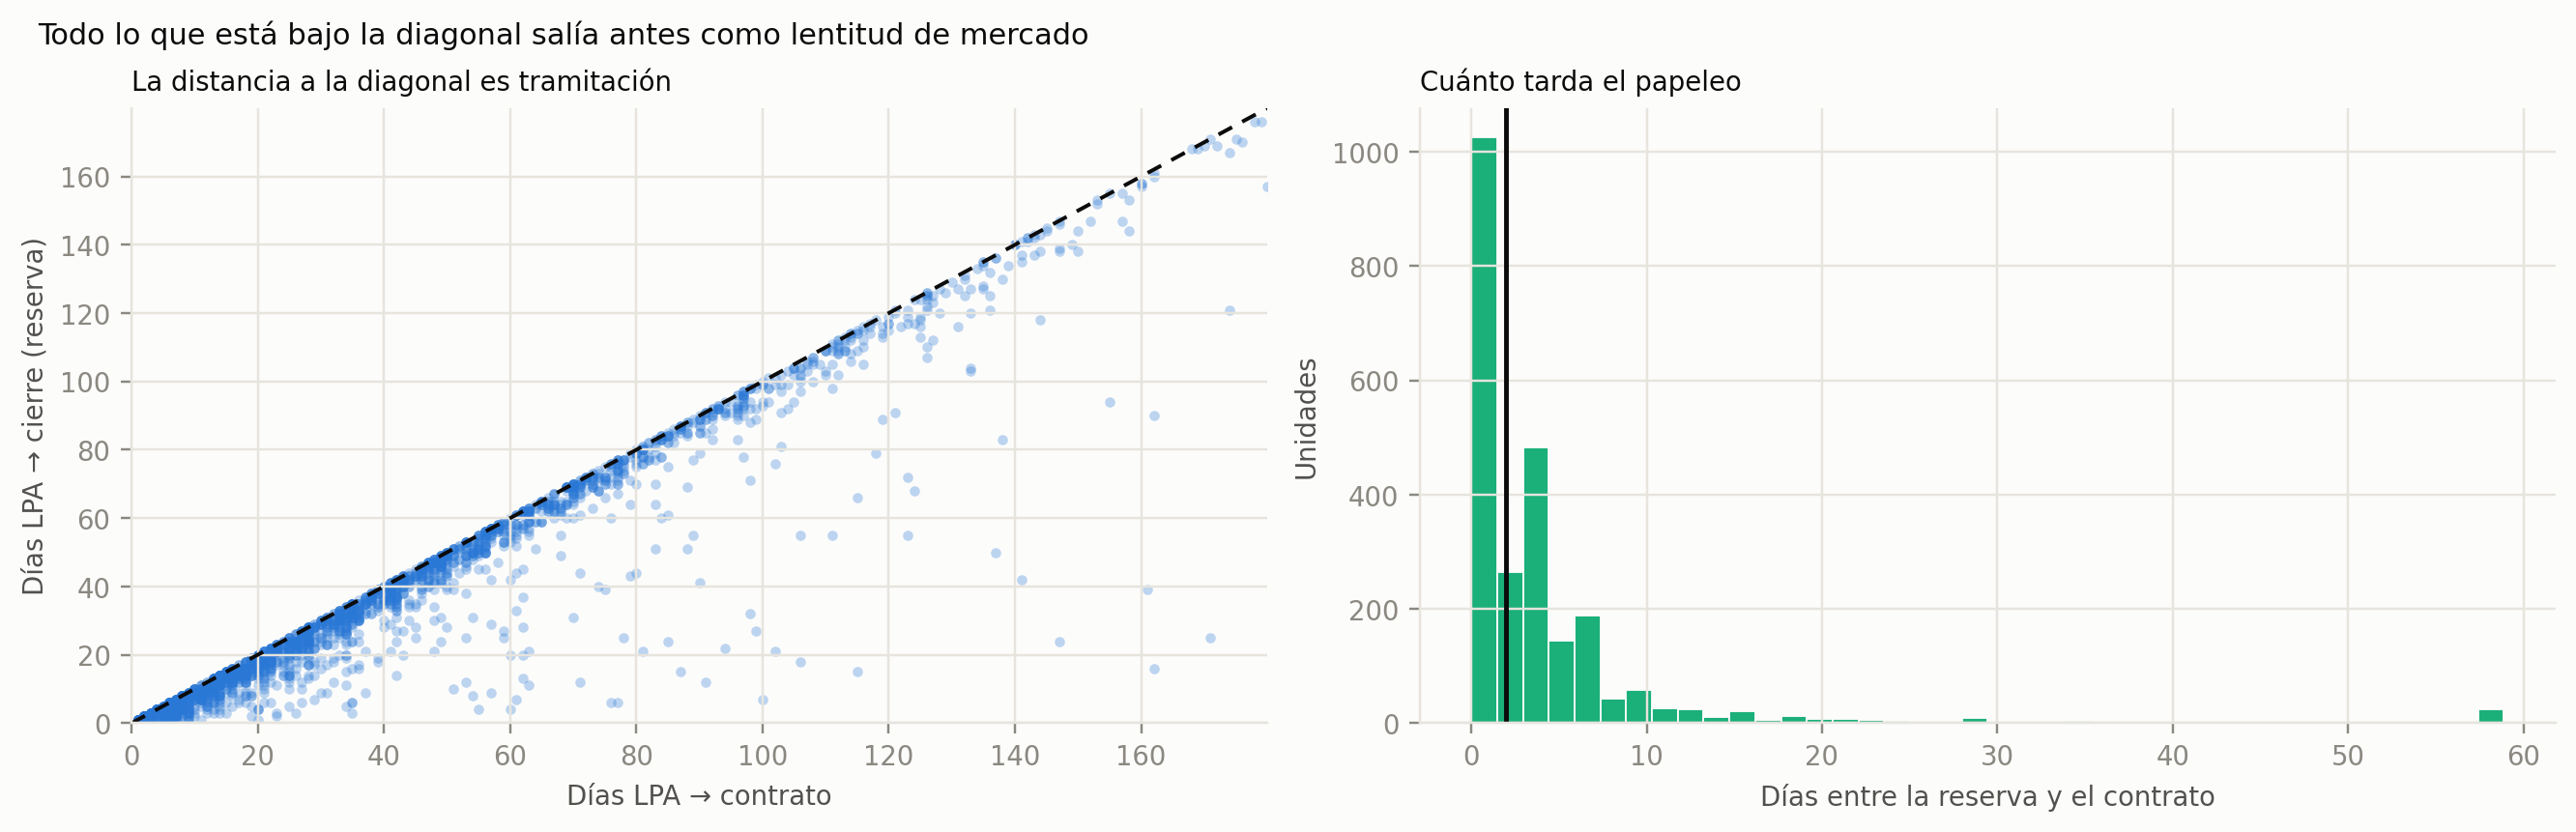

In [10]:
# Cuanto cambio el target respecto de medir contra el contrato.
comp = arr[arr["no_modelo_days_to_contrato"].notna()
           & arr["no_modelo_days_to_event"].notna()]
tram = (comp["no_modelo_days_to_contrato"] - comp["no_modelo_days_to_event"])

print(f"Días de tramitación (contrato − cierre), n = {len(comp):,}:")
print(f"  p50 {tram.median():.0f} · p90 {tram.quantile(0.9):.0f} · máx {tram.max():.0f}")
print(f"\nMediana de días a cierre   : {comp['no_modelo_days_to_event'].median():.0f}")
print(f"Mediana de días a contrato : {comp['no_modelo_days_to_contrato'].median():.0f}\n")

for h in HORIZONTES:
    a = (comp["no_modelo_days_to_contrato"] <= h).mean()
    b = (comp["no_modelo_days_to_event"]    <= h).mean()
    print(f"  colocadas en <= {h:>2}d:  por contrato {a:.1%}  ·  "
          f"por reserva {b:.1%}  ·  {b - a:+.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)

ax = axes[0]
tope = float(np.nanpercentile(comp["no_modelo_days_to_contrato"], 99))
ax.scatter(comp["no_modelo_days_to_contrato"], comp["no_modelo_days_to_event"],
           s=12, alpha=0.30, color=AZUL, linewidths=0)
ax.plot([0, tope], [0, tope], color=INK, lw=1.3, ls=(0, (4, 3)))
ax.set_xlim(0, tope); ax.set_ylim(0, tope)
ax.set_xlabel("Días LPA → contrato"); ax.set_ylabel("Días LPA → cierre (reserva)")
ax.set_title("La distancia a la diagonal es tramitación", fontsize=9, loc="left")

ax = axes[1]
g = tram[tram >= 0]
if len(g):
    ax.hist(g.clip(0, g.quantile(0.99)), bins=40, color=AQUA,
            edgecolor=SURFACE, linewidth=0.6)
    ax.axvline(g.median(), color=INK, lw=1.6)
ax.set_xlabel("Días entre la reserva y el contrato"); ax.set_ylabel("Unidades")
ax.set_title("Cuánto tarda el papeleo", fontsize=9, loc="left")

fig.suptitle("Todo lo que está bajo la diagonal salía antes como lentitud de mercado",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

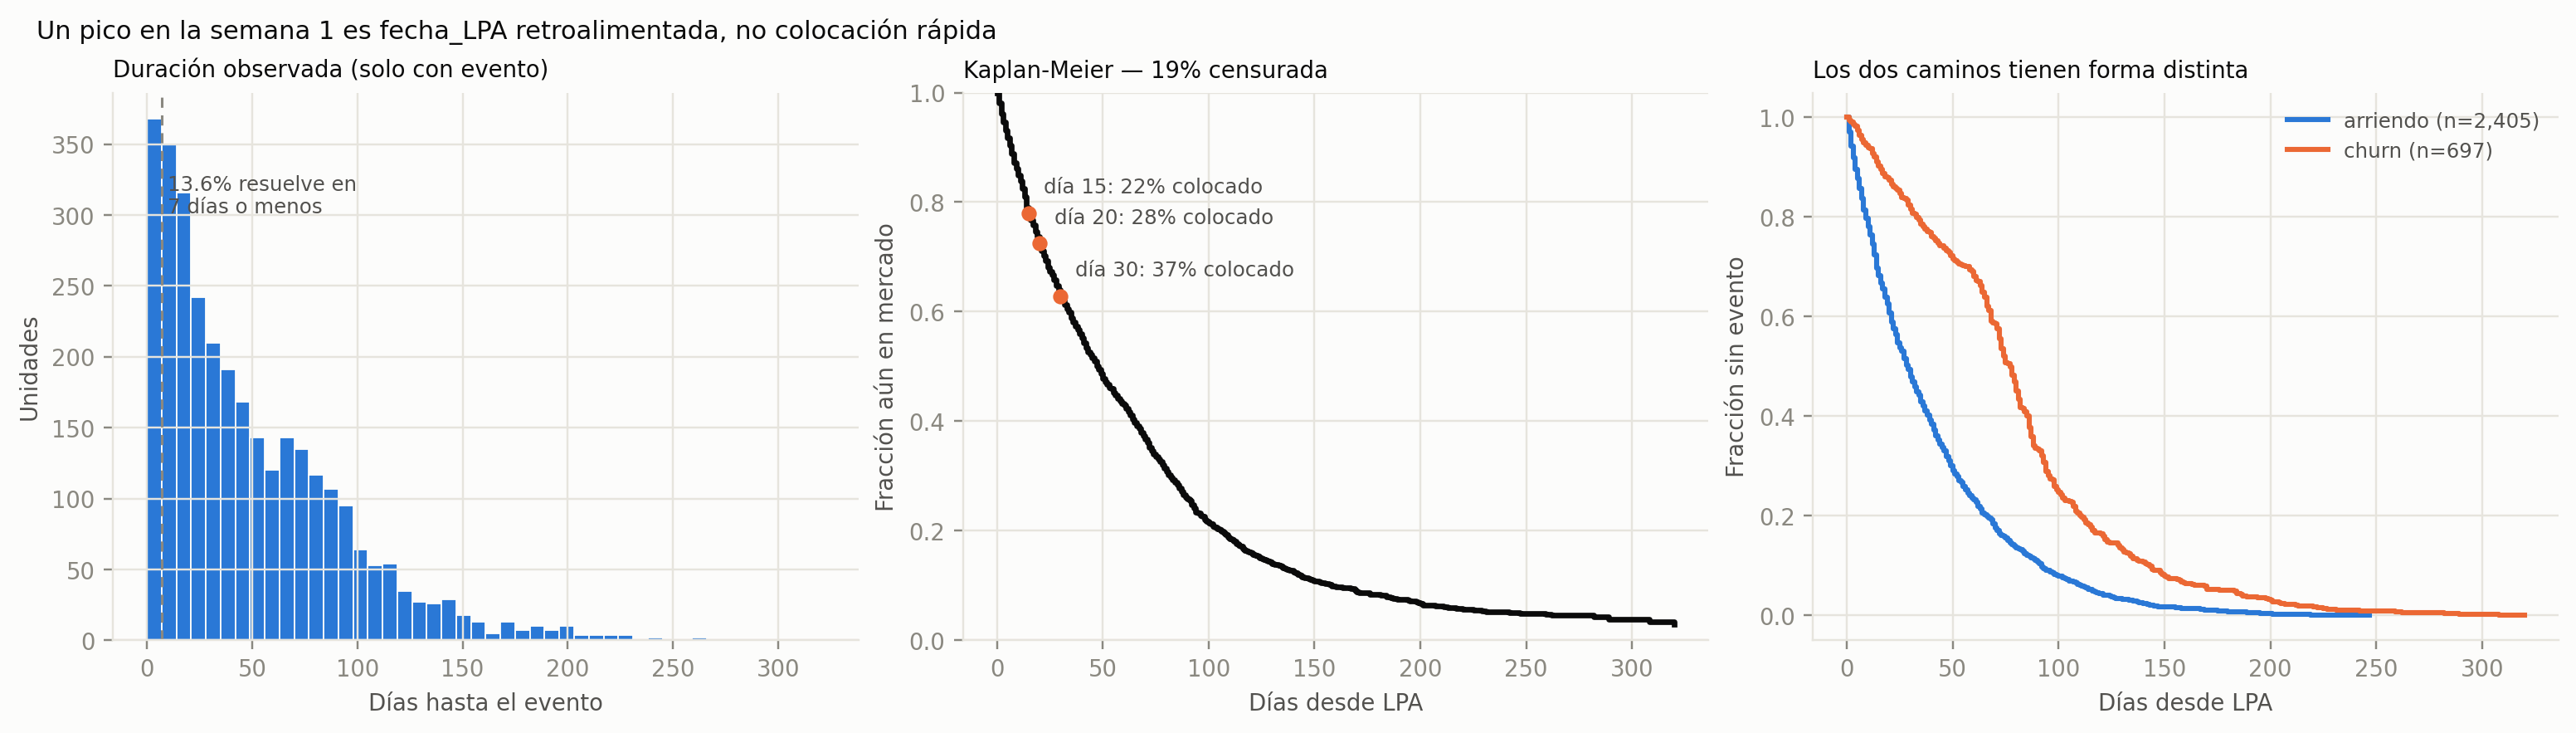

In [11]:
def kaplan_meier(dias, evento):
    '''Estimador KM sin dependencias externas.

    dias   : tiempo bajo observacion (nunca NULL)
    evento : 1 si el evento ocurrio, 0 si la observacion esta censurada

    Se implementa a mano en vez de importar lifelines para que el notebook corra
    en el entorno actual sin instalar nada; son quince lineas y el resultado es
    identico.
    '''
    dias   = np.asarray(dias, float)
    evento = np.asarray(evento, int)
    ok = np.isfinite(dias) & (dias >= 0)
    dias, evento = dias[ok], evento[ok]

    t_unicos = np.unique(dias[evento == 1])
    S, surv, tiempos = 1.0, [1.0], [0.0]
    for t in t_unicos:
        en_riesgo = (dias >= t).sum()
        fallos    = ((dias == t) & (evento == 1)).sum()
        if en_riesgo == 0:
            continue
        S *= (1 - fallos / en_riesgo)
        tiempos.append(t)
        surv.append(S)
    return np.array(tiempos), np.array(surv)


fig, axes = plt.subplots(1, 3, figsize=(14, 3.9), constrained_layout=True)

# --- 1. Distribucion de la duracion observada
ax = axes[0]
serie = d["no_modelo_days_to_event"].dropna()
bins = np.arange(0, serie.max() + 7, 7)
ax.hist(serie, bins=bins, color=AZUL, edgecolor=SURFACE, linewidth=0.6)
pico = (serie <= 7).mean()
ax.axvline(7, color=INK_MUTED, lw=1, ls=(0, (4, 3)))
ax.annotate(f"{pico:.1%} resuelve en\n7 días o menos",
            xy=(10, ax.get_ylim()[1] * 0.78), color=INK_SOFT, fontsize=8)
ax.set_xlabel("Días hasta el evento"); ax.set_ylabel("Unidades")
ax.set_title("Duración observada (solo con evento)", fontsize=9, loc="left")

# --- 2. Kaplan-Meier: censuradas incluidas
ax = axes[1]
t, s = kaplan_meier(d["no_modelo_dias_observados"], 1 - d["no_modelo_censurada"])
ax.step(t, s, where="post", color=INK, lw=2.2)
for h in HORIZONTES:
    if h <= t.max():
        s_h = s[t <= h][-1]
        ax.plot([h], [s_h], "o", color=NARANJA, ms=5)
        ax.annotate(f"día {h}: {1 - s_h:.0%} colocado", xy=(h, s_h),
                    xytext=(6, 8), textcoords="offset points",
                    color=INK_SOFT, fontsize=8)
ax.set_xlabel("Días desde LPA"); ax.set_ylabel("Fracción aún en mercado")
ax.set_ylim(0, 1)
ax.set_title(f"Kaplan-Meier — {d['no_modelo_censurada'].mean():.0%} censurada",
             fontsize=9, loc="left")

# --- 3. Los dos caminos por separado
ax = axes[2]
for tipo, color in [("arriendo", AZUL), ("churn", NARANJA)]:
    g = d[d["no_modelo_tipo_evento"] == tipo]
    if not len(g):
        continue
    t, s = kaplan_meier(g["no_modelo_dias_observados"], np.ones(len(g)))
    ax.step(t, s, where="post", color=color, lw=2, label=f"{tipo} (n={len(g):,})")
ax.set_xlabel("Días desde LPA"); ax.set_ylabel("Fracción sin evento")
ax.set_title("Los dos caminos tienen forma distinta", fontsize=9, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=INK_SOFT)

fig.suptitle("Un pico en la semana 1 es fecha_LPA retroalimentada, no colocación rápida",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

### Dos supuestos de la ventana de demanda, comprobados sobre los datos

**El universo ahora arranca el 2025-07-01**, alineado con el inicio de
`property_publication_metrics` (2025-07-23). Eso resuelve el problema anterior: antes había
cohortes enteras cuyas visitas eran cero por ausencia de tabla y no por ausencia de demanda.
Quedan ~3 semanas de colchón entre el filtro y el inicio real de la tabla, así que la primera
celda mide cuántas unidades caen todavía en ese hueco.

**La ventana de demanda es fija: `[fecha_LPA, fecha_LPA + 90 días)`, sin recorte por el
evento.** Es lo que permite que las tres agregaciones dependan solo de `lpa` y no de la
cadena cara — y además hace comparables los conteos, porque con ventana variable la unidad
que se arrendó el día 5 tiene 5 días de exposición y la que churneó el día 80 tiene 80.

El supuesto que sostiene esa decisión es que **una unidad arrendada sale de publicación y
deja de generar filas**. Si no fuera cierto, los conteos incluirían actividad posterior al
evento. La segunda celda lo comprueba comparando `last_visit_obs` con `event_date`: si la
fracción es baja, el supuesto se sostiene y la ventana fija es gratis; si es alta, hay que
volver a recortar en `event_date` y pagar el costo en SQL.

In [12]:
# 1 · El hueco entre el filtro del universo y el inicio real de la tabla.
INICIO_METRICAS = pd.Timestamp("2025-07-23")   # MIN(date_from) medido en la base

en_hueco = d["fecha_LPA"] < INICIO_METRICAS
print(f"Unidades con fecha_LPA anterior al inicio de la tabla de métricas: "
      f"{en_hueco.sum():,} de {len(d):,} ({en_hueco.mean():.1%})")
if en_hueco.any():
    print(f"  de esas, sin ninguna visita registrada: "
          f"{d.loc[en_hueco, 'flag_sin_datos_visitas'].mean():.1%}")
print(f"  del resto, sin ninguna visita registrada: "
      f"{d.loc[~en_hueco, 'flag_sin_datos_visitas'].mean():.1%}   <- este sí es un cero real")

display(d.groupby("cohorte_lpa")
         .agg(n            = ("property_id", "size"),
              sin_visitas  = ("flag_sin_datos_visitas", "mean"),
              visitas_d0_7 = ("d0_7_visitas", "mean"),
              leads_d0_7   = ("d0_7_leads", "mean"),
              reservas_90d = ("no_modelo_reservas_90d", "mean"))
         .round(3))

Unidades con fecha_LPA anterior al inicio de la tabla de métricas: 41 de 3,834 (1.1%)
  de esas, sin ninguna visita registrada: 12.2%
  del resto, sin ninguna visita registrada: 7.8%   <- este sí es un cero real


,n,sin_visitas,visitas_d0_7,leads_d0_7,reservas_90d
cohorte_lpa,,,,,
2025-07,97,0.052,4.990,0.361,0.722
2025-08,171,0.035,9.789,0.480,0.684
2025-09,185,0.054,11.562,0.422,0.638
2025-10,178,0.051,9.775,0.826,0.736
2025-11,232,0.065,8.819,1.108,0.784
2025-12,435,0.078,4.685,0.703,0.664
2026-01,276,0.043,11.388,1.815,0.707
2026-02,306,0.111,13.343,2.134,0.706
2026-03,419,0.053,12.289,1.518,0.675


In [13]:
# 2 · El supuesto de la ventana fija: ¿hay actividad DESPUES del evento?
con_ambas = d[d["no_modelo_event_date"].notna() & d["no_modelo_last_visit_obs"].notna()].copy()
post = pd.to_datetime(con_ambas["no_modelo_last_visit_obs"]) > con_ambas["no_modelo_event_date"]

print(f"Unidades con evento y con visitas observadas: {len(con_ambas):,}")
print(f"  con última visita POSTERIOR al evento: {post.mean():.1%}")

if post.any():
    dias = (pd.to_datetime(con_ambas.loc[post, "no_modelo_last_visit_obs"])
            - con_ambas.loc[post, "no_modelo_event_date"]).dt.days
    print(f"  mediana de días de cola post-evento: {dias.median():.0f}  "
          f"(p90 = {dias.quantile(0.9):.0f})")

print(
    "\nLectura: bajo ~10% y con colas cortas, la ventana fija de 90 días es equivalente\n"
    "a recortar en el evento y no hay nada que corregir. Muy por encima de eso, los\n"
    "conteos de demanda están contaminados con actividad post-arriendo y hay que volver\n"
    "a recortar la ventana en event_date dentro de la query."
)

Unidades con evento y con visitas observadas: 2,905
  con última visita POSTERIOR al evento: 22.0%
  mediana de días de cola post-evento: 2  (p90 = 27)

Lectura: bajo ~10% y con colas cortas, la ventana fija de 90 días es equivalente
a recortar en el evento y no hay nada que corregir. Muy por encima de eso, los
conteos de demanda están contaminados con actividad post-arriendo y hay que volver
a recortar la ventana en event_date dentro de la query.


In [14]:
# Madurez de cada cohorte. Las cohortes recientes llevan poco tiempo observadas,
# asi que su tasa de "colocado en 20 dias" no es comparable con las antiguas si
# uno no controla por censura. Esta tabla dice cuales son comparables.
coh = (d.groupby("cohorte_lpa")
         .agg(n            = ("property_id", "size"),
              censurada    = ("no_modelo_censurada", "mean"),
              dias_obs_p50 = ("no_modelo_dias_observados", "median"),
              churn        = ("no_modelo_churn", "mean"),
              y_20         = ("y_20", "mean"),
              y_20_obs     = ("y_20", lambda s: s.notna().mean()))
         .round(3))
display(coh)
print("y_20_obs < 1 significa que en esa cohorte todavia hay unidades cuyo desenlace\n"
      "a 20 dias no se sabe. Bajo ~0,9 la tasa y_20 de esa cohorte no es comparable.")

,n,censurada,dias_obs_p50,churn,y_20,y_20_obs
cohorte_lpa,,,,,,
2025-07,97,0.000,47.000,0.299,0.278,1.000
2025-08,171,0.012,40.000,0.287,0.287,1.000
2025-09,185,0.016,35.000,0.346,0.216,1.000
2025-10,178,0.017,30.000,0.219,0.320,1.000
2025-11,232,0.017,41.500,0.198,0.280,1.000
2025-12,435,0.090,58.000,0.110,0.172,1.000
2026-01,276,0.051,40.000,0.203,0.326,1.000
2026-02,306,0.039,37.000,0.193,0.363,1.000
2026-03,419,0.117,46.000,0.158,0.315,1.000


y_20_obs < 1 significa que en esa cohorte todavia hay unidades cuyo desenlace
a 20 dias no se sabe. Bajo ~0,9 la tasa y_20 de esa cohorte no es comparable.


## Paso 3 · Univariado

Antes de preguntar si una variable mueve la velocidad, hay que saber qué hay dentro. Lo que se
busca acá: **faltantes** (¿son informativos o aleatorios?), **cardinalidad** en las categóricas
(una con 400 niveles no se puede leer ni codificar directo), y **colas** en las numéricas (un
efecto que viene de tres observaciones extremas no es un efecto).

In [15]:
FEATURES_NUM = ["m2_utiles", "m2_por_dormitorio", "piso", "dormitorios", "banos",
                "precio_oferta", "precio_m2", "ggcc", "dias_habilitacion",
                "acepta_mascotas", "estudio"]
FEATURES_CAT = ["comuna", "sector_provincia", "nombre_tipologia", "owner_type",
                "grupo_edificio", "tipologia_origen"]

perfil = pd.DataFrame({
    "n_no_nulo":  d[FEATURES_NUM].notna().sum(),
    "pct_faltante": d[FEATURES_NUM].isna().mean(),
    "media":      d[FEATURES_NUM].mean(),
    "sd":         d[FEATURES_NUM].std(),
    "p01":        d[FEATURES_NUM].quantile(0.01),
    "p50":        d[FEATURES_NUM].median(),
    "p99":        d[FEATURES_NUM].quantile(0.99),
    "n_ceros":    (d[FEATURES_NUM] == 0).sum(),
})
display(perfil.round(2))

,n_no_nulo,pct_faltante,media,sd,p01,p50,p99,n_ceros
m2_utiles,3728,0.030,39.790,13.190,20.890,35.000,82.730,0
m2_por_dormitorio,3728,0.030,27.770,6.350,15.300,28.000,45.000,0
piso,3834,0.000,6.900,6.980,0.000,5.000,25.670,1179
dormitorios,3834,0.000,1.520,0.660,1.000,1.000,3.000,0
banos,3834,0.000,1.270,0.470,1.000,1.000,2.000,0
precio_oferta,3834,0.000,"408,004.010","143,512.870","233,512.000","380,000.000","940,100.000",0
precio_m2,3728,0.030,"10,521.340","2,295.550","6,693.370","10,278.000","18,607.500",0
ggcc,3171,0.170,"72,901.290","33,577.950","25,000.000","65,000.000","170,000.000",0
dias_habilitacion,3834,0.000,37.190,50.730,0.000,18.000,223.000,83
acepta_mascotas,3834,0.000,0.780,0.410,0.000,1.000,1.000,832


In [16]:
# El faltante, ¿es informativo? Si las filas sin el dato tienen otra velocidad,
# el propio indicador de faltante es una feature y NO se puede imputar en
# silencio: imputar borraria la senal.
filas = []
for c in FEATURES_NUM:
    m = d[c].isna()
    if m.sum() < 10 or m.all():
        continue
    filas.append({
        "variable": c,
        "n_faltante": int(m.sum()),
        "pct": m.mean(),
        "y_20_con_dato": d.loc[~m, "y_20"].mean(),
        "y_20_sin_dato": d.loc[m,  "y_20"].mean(),
        "churn_con_dato": d.loc[~m, "no_modelo_churn"].mean(),
        "churn_sin_dato": d.loc[m,  "no_modelo_churn"].mean(),
    })
if filas:
    t = pd.DataFrame(filas)
    t["delta_y20"] = t["y_20_sin_dato"] - t["y_20_con_dato"]
    display(t.round(3).sort_values("delta_y20", key=abs, ascending=False))
    print("delta_y20 grande => el faltante es informativo. Imputar sin indicador borra senal.")
else:
    print("Sin variables numericas con faltantes relevantes (>= 10 filas).")

,variable,n_faltante,pct,y_20_con_dato,y_20_sin_dato,churn_con_dato,churn_sin_dato,delta_y20
3,ggcc,663,0.173,0.281,0.138,0.137,0.398,-0.143
0,m2_utiles,106,0.028,0.258,0.192,0.179,0.283,-0.067
1,m2_por_dormitorio,106,0.028,0.258,0.192,0.179,0.283,-0.067
2,precio_m2,106,0.028,0.258,0.192,0.179,0.283,-0.067


delta_y20 grande => el faltante es informativo. Imputar sin indicador borra senal.


In [17]:
# Cardinalidad y concentracion de las categoricas.
filas = []
for c in FEATURES_CAT:
    vc = d[c].astype("string").fillna("(nulo)").value_counts()
    filas.append({
        "variable": c,
        "n_niveles": len(vc),
        "nivel_top": vc.index[0],
        "pct_top": vc.iloc[0] / len(d),
        f"niveles_con_n<{MIN_OBS}": int((vc < MIN_OBS).sum()),
        f"pct_en_niveles_chicos": vc[vc < MIN_OBS].sum() / len(d),
        "pct_nulo": d[c].isna().mean(),
    })
display(pd.DataFrame(filas).round(3))
print(f"\nUn 'pct_en_niveles_chicos' alto obliga a agrupar en 'Otras' antes de cualquier\n"
      f"corte por categoria: celdas con n < {MIN_OBS} dan tasas que son ruido.")

,variable,n_niveles,nivel_top,pct_top,niveles_con_n<30,pct_en_niveles_chicos,pct_nulo
0,comuna,26,Santiago,0.254,14,0.045,0.000
1,sector_provincia,7,Santiago - Centro,0.254,0,0.000,0.000
2,nombre_tipologia,7,1D1B,0.463,2,0.009,0.000
3,owner_type,2,old,0.742,0,0.000,0.000
4,grupo_edificio,796,Edificio Vertice,0.067,775,0.573,0.000
5,tipologia_origen,4,D y B,0.811,1,0.008,0.000



Un 'pct_en_niveles_chicos' alto obliga a agrupar en 'Otras' antes de cualquier
corte por categoria: celdas con n < 30 dan tasas que son ruido.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

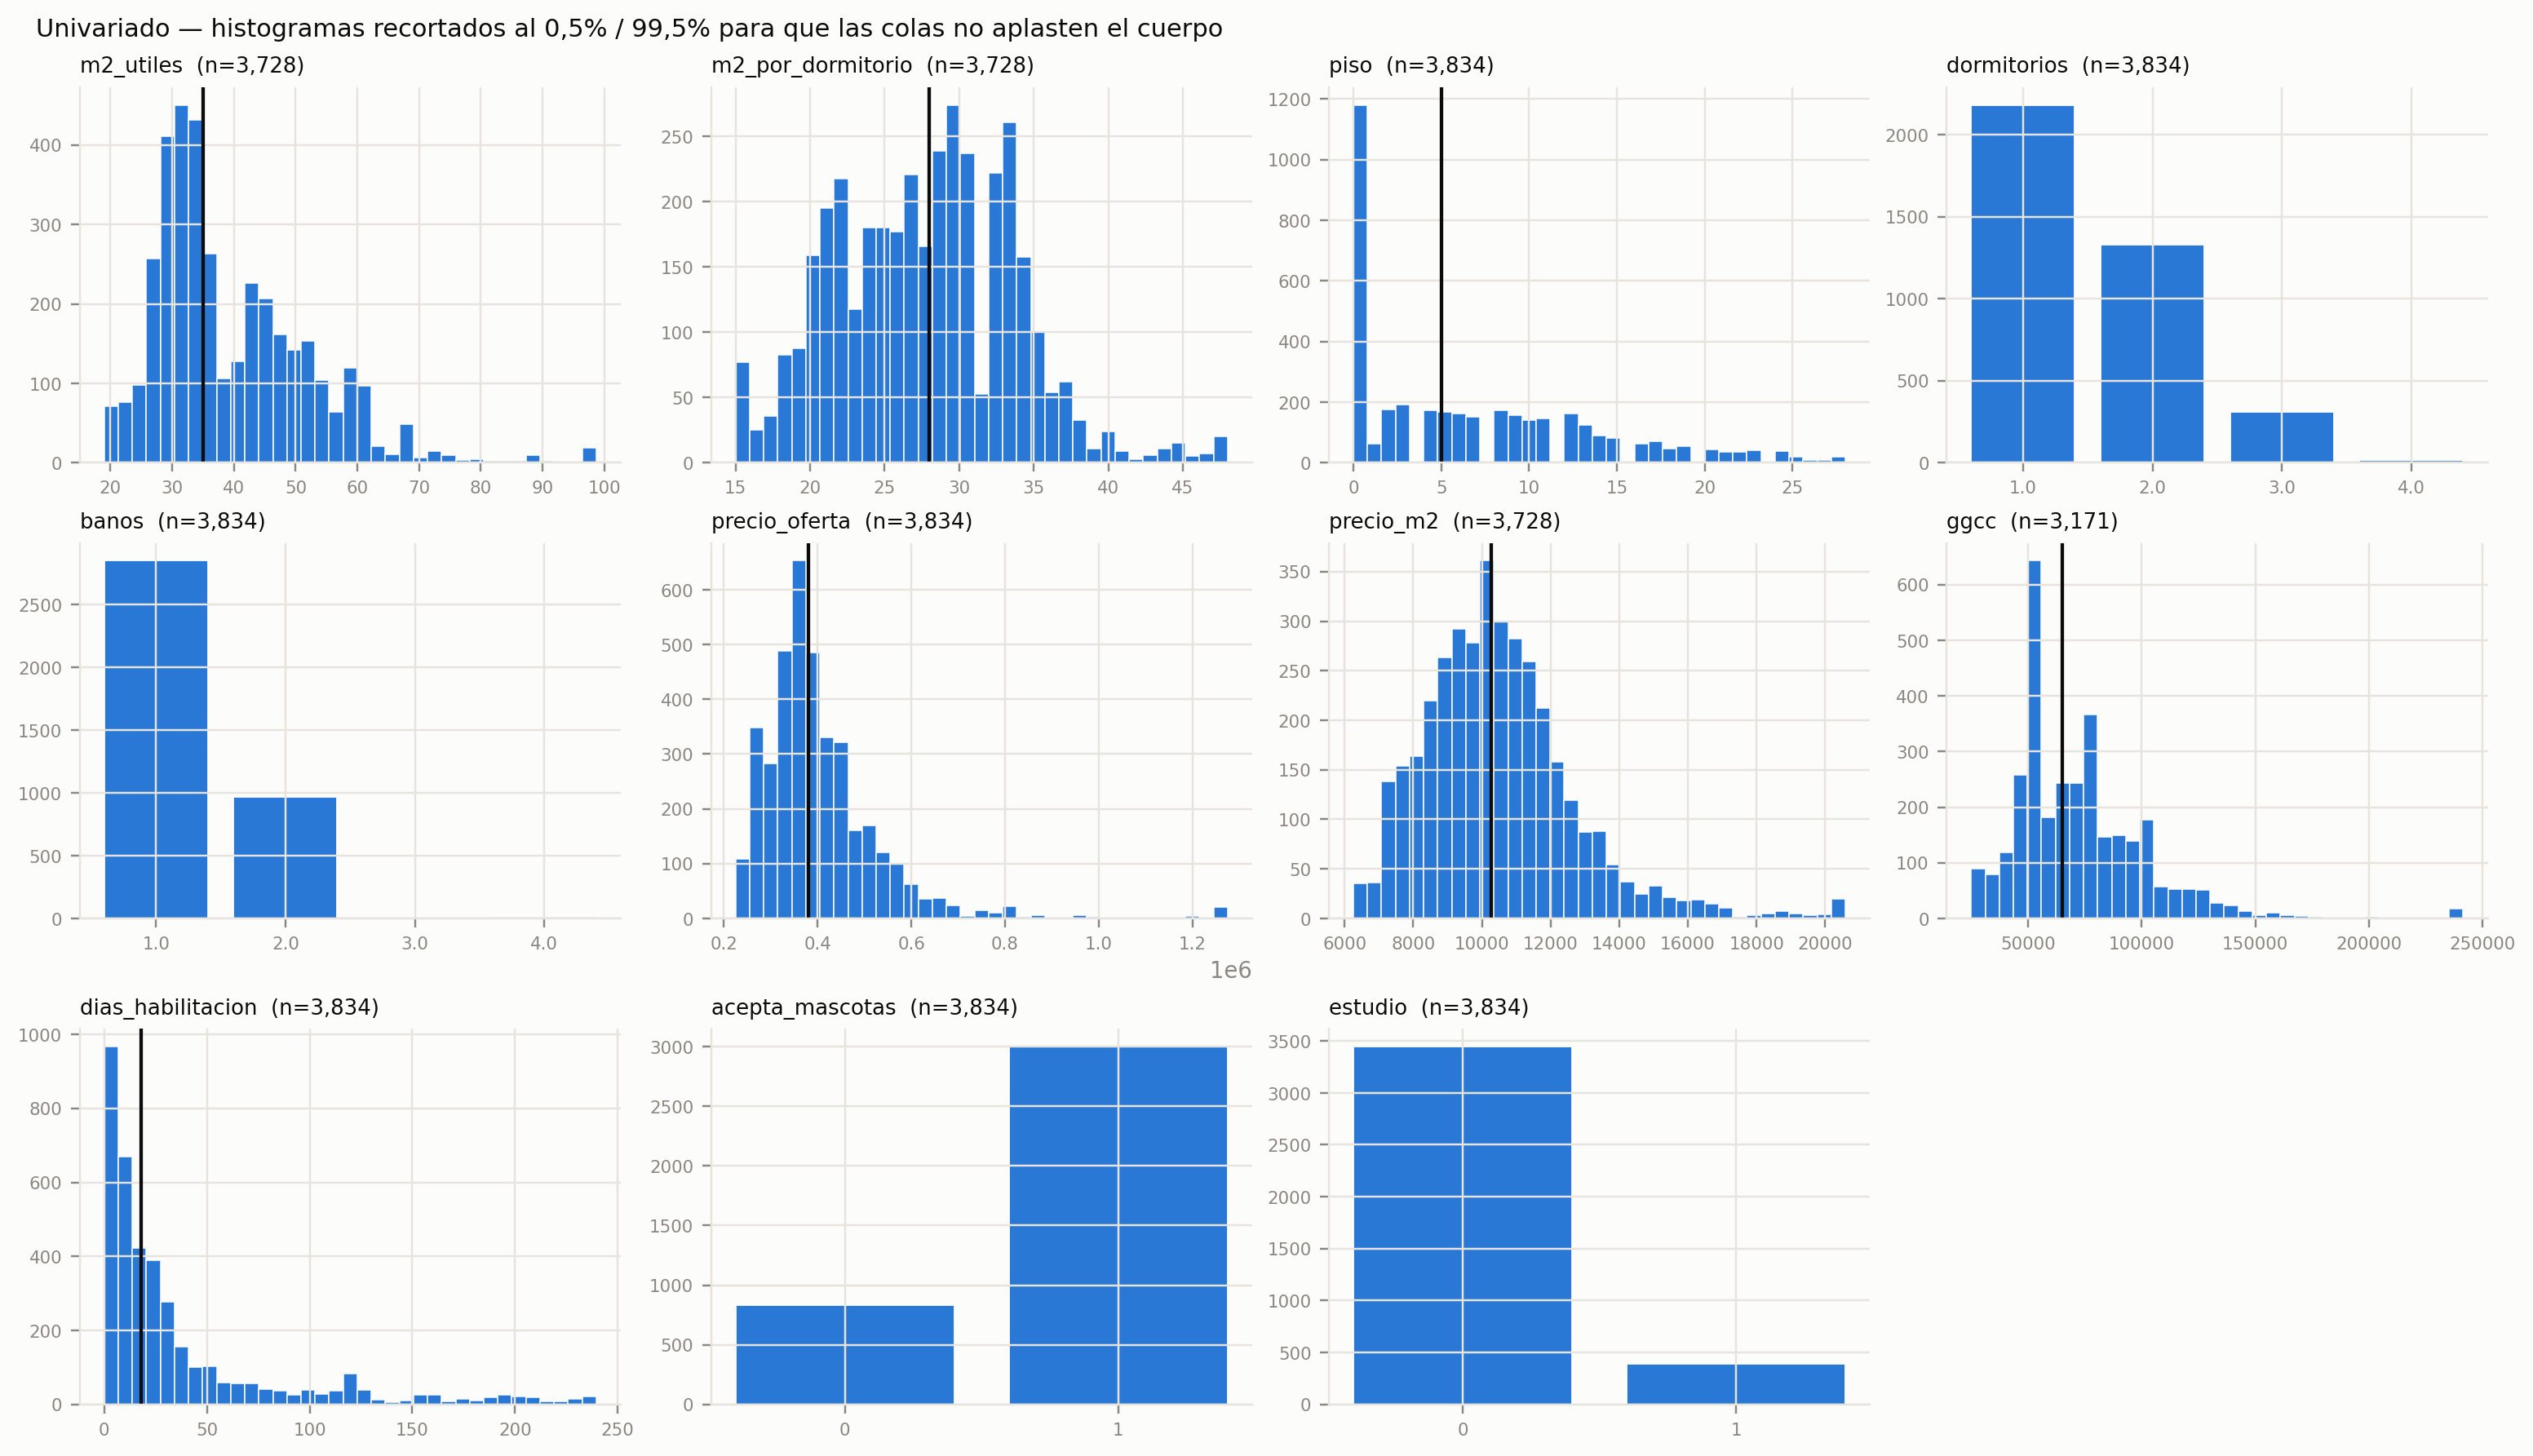

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(14, 8), constrained_layout=True)
for ax, c in zip(axes.ravel(), FEATURES_NUM):
    s = d[c].dropna()
    if s.nunique() <= 12:
        vc = s.value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color=AZUL, edgecolor=SURFACE, linewidth=0.6)
    else:
        lo, hi = s.quantile([0.005, 0.995])
        ax.hist(s.clip(lo, hi), bins=35, color=AZUL, edgecolor=SURFACE, linewidth=0.5)
        ax.axvline(s.median(), color=INK, lw=1.4)
    ax.set_title(f"{c}  (n={len(s):,})", fontsize=8.5, loc="left")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(FEATURES_NUM):]:
    ax.set_visible(False)
fig.suptitle("Univariado — histogramas recortados al 0,5% / 99,5% para que las colas no aplasten el cuerpo",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

## Paso 4 · Bivariado: ¿cada variable mueve la velocidad?

Dos herramientas, una para cada tipo de variable, y las dos deliberadamente **sin ajustar una
recta**. Si la relación es de umbral — nada pasa con desviaciones de ±5%, todo pasa sobre 15% —
una pendiente lineal da cerca de cero y esconde justamente el patrón que buscamos.

Cada variable se mira contra **dos** outcomes a la vez: los días hasta arriendo (solo entre las
que arrendaron) y la tasa de churn (sobre todas). Es la separación del paso 4 del diagnóstico
anterior, y no es cosmética: son los dos caminos que se cancelan cuando se los mezcla.

In [19]:
def perfil_por_bin(datos, var, n_bins=10, y="y_20"):
    '''Resumen del outcome por decil de una variable continua.

    No ajusta pendiente a proposito: devuelve el perfil por bin para que una
    relacion no monotona (umbral, U invertida) sea visible en vez de colapsar
    a un coeficiente cercano a cero.
    '''
    t = datos[datos[var].notna()].copy()
    if t[var].nunique() < 3:
        return pd.DataFrame()
    t["_bin"] = pd.qcut(t[var], min(n_bins, t[var].nunique()),
                        duplicates="drop", labels=False)
    arr = lambda g: g[g["no_modelo_tipo_evento"] == "arriendo"]
    out = t.groupby("_bin").apply(lambda g: pd.Series({
        "n":          len(g),
        "x_p50":      g[var].median(),
        y:            g[y].mean(),
        "n_arrendadas": len(arr(g)),
        "dias_p50":   arr(g)["no_modelo_days_to_event"].median(),
        "dias_media": arr(g)["no_modelo_days_to_event"].mean(),
        "dias_se":    arr(g)["no_modelo_days_to_event"].std() / np.sqrt(max(len(arr(g)), 1)),
        "churn":      g["no_modelo_churn"].mean(),
        "censurada":  g["no_modelo_censurada"].mean(),
    }), include_groups=False)
    return out


def perfil_por_categoria(datos, var, y="y_20", min_obs=MIN_OBS):
    '''Mismo resumen, agrupando niveles chicos en "Otras".'''
    t = datos.copy()
    s = t[var].astype("string").fillna("(nulo)")
    vc = s.value_counts()
    t["_cat"] = s.where(~s.isin(vc[vc < min_obs].index), "Otras")
    arr = lambda g: g[g["no_modelo_tipo_evento"] == "arriendo"]
    out = t.groupby("_cat").apply(lambda g: pd.Series({
        "n":          len(g),
        y:            g[y].mean(),
        "dias_p50":   arr(g)["no_modelo_days_to_event"].median(),
        "dias_media": arr(g)["no_modelo_days_to_event"].mean(),
        "dias_se":    arr(g)["no_modelo_days_to_event"].std() / np.sqrt(max(len(arr(g)), 1)),
        "churn":      g["no_modelo_churn"].mean(),
        "censurada":  g["no_modelo_censurada"].mean(),
    }), include_groups=False).sort_values("n", ascending=False)
    return out


def mediana_por_bin(datos, xvar, yvar, n_bins=12):
    '''Mediana e IQR de y por cuantil de x. Devuelve una fila por bin.

    Deliberadamente no ajusta una recta: si la relacion es de umbral (nada pasa
    con desviaciones de +-5%, todo pasa sobre 15%), una pendiente lineal da ~0 y
    esconde justamente el patron que buscamos.
    '''
    t = datos[[xvar, yvar]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(t) < 15:
        return pd.DataFrame(columns=["x", "p25", "p50", "p75", "n"])
    x, y = t[xvar].values, t[yvar].values
    if len(x) < n_bins * 5:
        n_bins = max(3, len(x) // 25)
    bordes = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
    if len(bordes) < 3:
        return pd.DataFrame(columns=["x", "p25", "p50", "p75", "n"])
    idx = np.clip(np.digitize(x, bordes[1:-1]), 0, len(bordes) - 2)
    filas = []
    for b in range(len(bordes) - 1):
        m = idx == b
        if m.sum() < 5:
            continue
        q = np.percentile(y[m], [25, 50, 75])
        filas.append((np.median(x[m]), q[0], q[1], q[2], int(m.sum())))
    return pd.DataFrame(filas, columns=["x", "p25", "p50", "p75", "n"])

In [20]:
# Ranking de asociacion. Rango entre deciles extremos, no correlacion lineal:
# una U invertida da r ~ 0 y aca aparece como rango grande.
# se_dif da la escala del ruido: una diferencia menor a ~2 errores estandar no
# se distingue de cero con esta muestra.
filas = []
for c in FEATURES_NUM:
    p = perfil_por_bin(d, c)
    if len(p) < 3:
        continue
    lo, hi = p.iloc[:2], p.iloc[-2:]
    dias_lo = np.average(lo["dias_media"].fillna(0), weights=lo["n_arrendadas"].clip(lower=1))
    dias_hi = np.average(hi["dias_media"].fillna(0), weights=hi["n_arrendadas"].clip(lower=1))
    se = np.sqrt(np.nansum(lo["dias_se"] ** 2) + np.nansum(hi["dias_se"] ** 2))
    filas.append({
        "variable": c,
        "y20_min": p["y_20"].min(), "y20_max": p["y_20"].max(),
        "y20_rango": p["y_20"].max() - p["y_20"].min(),
        "dias_deciles_bajos": dias_lo,
        "dias_deciles_altos": dias_hi,
        "dias_dif": dias_hi - dias_lo,
        "se_dif": se,
        "n_se": abs(dias_hi - dias_lo) / se if se > 0 else np.nan,
        "churn_rango": p["churn"].max() - p["churn"].min(),
    })
rank = pd.DataFrame(filas).sort_values("y20_rango", ascending=False)
display(rank.round(3))
print("Ordenado por cuanto mueve y_20 entre deciles. n_se >= 2 en dias_dif es la senal\n"
      "de que la diferencia de duracion no es ruido de muestreo.")

,variable,y20_min,y20_max,y20_rango,dias_deciles_bajos,dias_deciles_altos,dias_dif,se_dif,n_se,churn_rango
0,m2_utiles,0.201,0.412,0.212,40.998,38.692,-2.306,4.584,0.503,0.107
5,ggcc,0.214,0.418,0.204,45.497,34.306,-11.191,5.221,2.143,0.176
3,precio_oferta,0.196,0.390,0.193,42.050,31.138,-10.911,4.395,2.483,0.160
6,dias_habilitacion,0.213,0.363,0.150,42.432,35.666,-6.766,4.867,1.390,0.227
1,m2_por_dormitorio,0.211,0.315,0.104,42.489,33.544,-8.946,5.351,1.672,0.195
4,precio_m2,0.226,0.322,0.096,42.294,39.930,-2.364,5.098,0.464,0.181
2,piso,0.204,0.296,0.092,36.365,48.013,11.648,4.591,2.537,0.179


Ordenado por cuanto mueve y_20 entre deciles. n_se >= 2 en dias_dif es la senal
de que la diferencia de duracion no es ruido de muestreo.


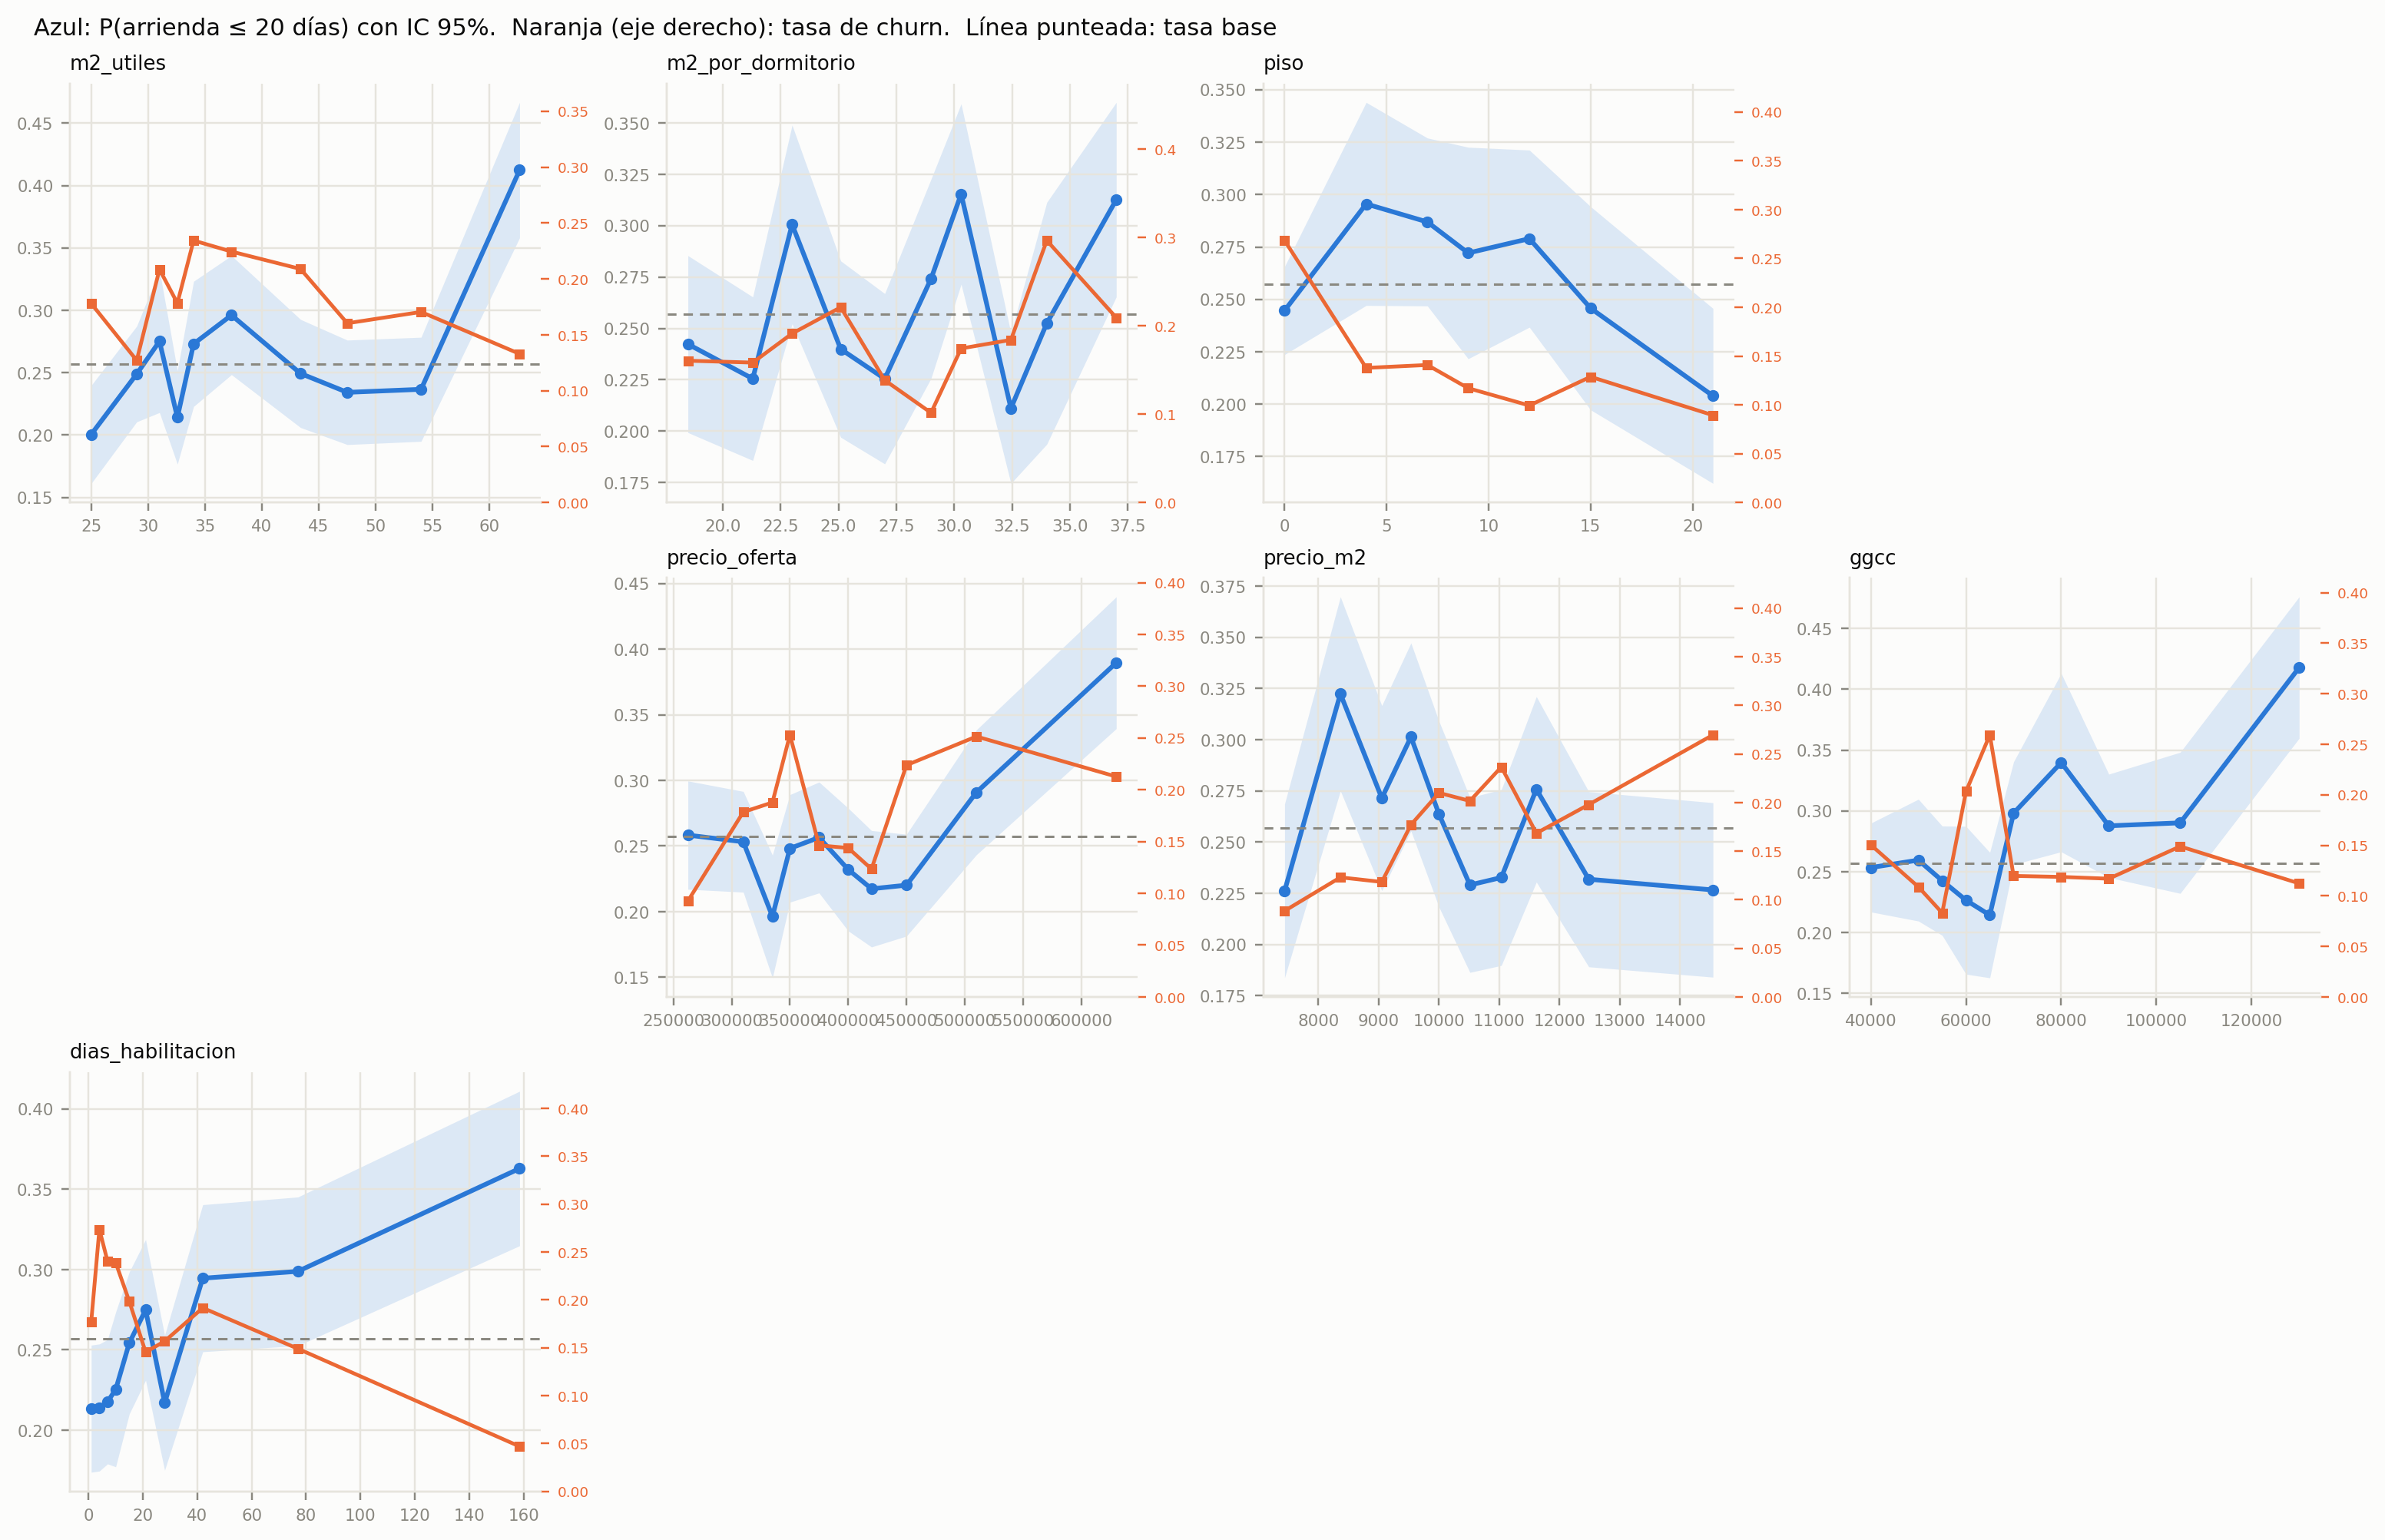

In [21]:
fig, axes = plt.subplots(3, 4, figsize=(14, 9), constrained_layout=True)
for ax, c in zip(axes.ravel(), FEATURES_NUM):
    p = perfil_por_bin(d, c)
    if len(p) < 3:
        ax.set_visible(False); continue
    ax.plot(p["x_p50"], p["y_20"], color=AZUL, lw=2, marker="o", ms=4)
    ax.fill_between(p["x_p50"],
                    p["y_20"] - 1.96 * np.sqrt(p["y_20"] * (1 - p["y_20"]) / p["n"]),
                    p["y_20"] + 1.96 * np.sqrt(p["y_20"] * (1 - p["y_20"]) / p["n"]),
                    color=AZUL, alpha=0.15, linewidth=0)
    ax.axhline(d["y_20"].mean(), color=INK_MUTED, lw=1, ls=(0, (4, 3)))
    ax2 = ax.twinx()
    ax2.plot(p["x_p50"], p["churn"], color=NARANJA, lw=1.6, marker="s", ms=3)
    ax2.set_ylim(0, max(p["churn"].max() * 1.6, 0.05))
    ax2.grid(False); ax2.tick_params(labelsize=6, colors=NARANJA)
    ax.set_title(c, fontsize=8.5, loc="left")
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(FEATURES_NUM):]:
    ax.set_visible(False)
fig.suptitle("Azul: P(arrienda ≤ 20 días) con IC 95%.  Naranja (eje derecho): tasa de churn.  "
             "Línea punteada: tasa base",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

In [22]:
# Categoricas: tabla por nivel para las de cardinalidad manejable.
for c in ["sector_provincia", "nombre_tipologia", "owner_type", "comuna"]:
    p = perfil_por_categoria(d, c)
    print(f"\n=== {c} ===")
    display(p.round(3))


=== sector_provincia ===


,n,y_20,dias_p50,dias_media,dias_se,churn,censurada
_cat,,,,,,,
Santiago - Centro,974.000,0.297,24.000,35.625,1.405,0.175,0.175
Santiago - Norte,720.000,0.181,47.000,54.937,1.862,0.074,0.203
Santiago - Suroriente,688.000,0.244,27.000,36.850,1.656,0.240,0.167
Santiago - Sur,544.000,0.272,23.500,39.172,2.220,0.199,0.191
Santiago - Surponiente,517.000,0.162,37.000,44.941,2.282,0.226,0.280
Santiago - Nororiente,338.000,0.463,12.000,22.357,1.675,0.204,0.115
Santiago - Norponiente,53.000,0.154,31.000,36.120,5.341,0.283,0.245



=== nombre_tipologia ===


,n,y_20,dias_p50,dias_media,dias_se,churn,censurada
_cat,,,,,,,
1D1B,"1,776.000",0.260,29.000,38.948,1.062,0.182,0.173
2D2B,790.000,0.255,30.000,43.180,1.785,0.168,0.170
2D1B,537.000,0.271,24.000,35.542,2.036,0.220,0.203
Estudio,388.000,0.178,38.000,43.995,2.443,0.198,0.284
3D,309.000,0.317,22.500,42.144,3.016,0.123,0.223
Otras,34.000,0.294,42.500,50.042,11.319,0.235,0.059



=== owner_type ===


,n,y_20,dias_p50,dias_media,dias_se,churn,censurada
_cat,,,,,,,
old,"2,846.000",0.253,31.000,42.256,0.924,0.162,0.193
new,988.000,0.270,24.000,33.707,1.288,0.238,0.185



=== comuna ===


,n,y_20,dias_p50,dias_media,dias_se,churn,censurada
_cat,,,,,,,
Santiago,974.000,0.297,24.000,35.625,1.405,0.175,0.175
Independencia,527.000,0.171,47.000,56.434,2.272,0.080,0.186
La Florida,494.000,0.229,30.500,39.279,2.075,0.265,0.132
Estación Central,294.000,0.217,35.000,40.875,2.403,0.153,0.194
Ñuñoa,270.000,0.475,12.000,21.286,1.643,0.200,0.100
La Cisterna,243.000,0.335,21.000,30.304,2.431,0.243,0.095
Cerrillos,202.000,0.069,57.000,60.981,6.013,0.312,0.431
Macul,190.000,0.282,23.000,30.421,2.413,0.174,0.263
Otras,173.000,0.308,23.000,35.215,3.232,0.225,0.156


Edificios con n >= 30: 21  (cubren 43% de la muestra)
y_20 va de 0.02 a 0.87 entre edificios (tasa global 0.26)


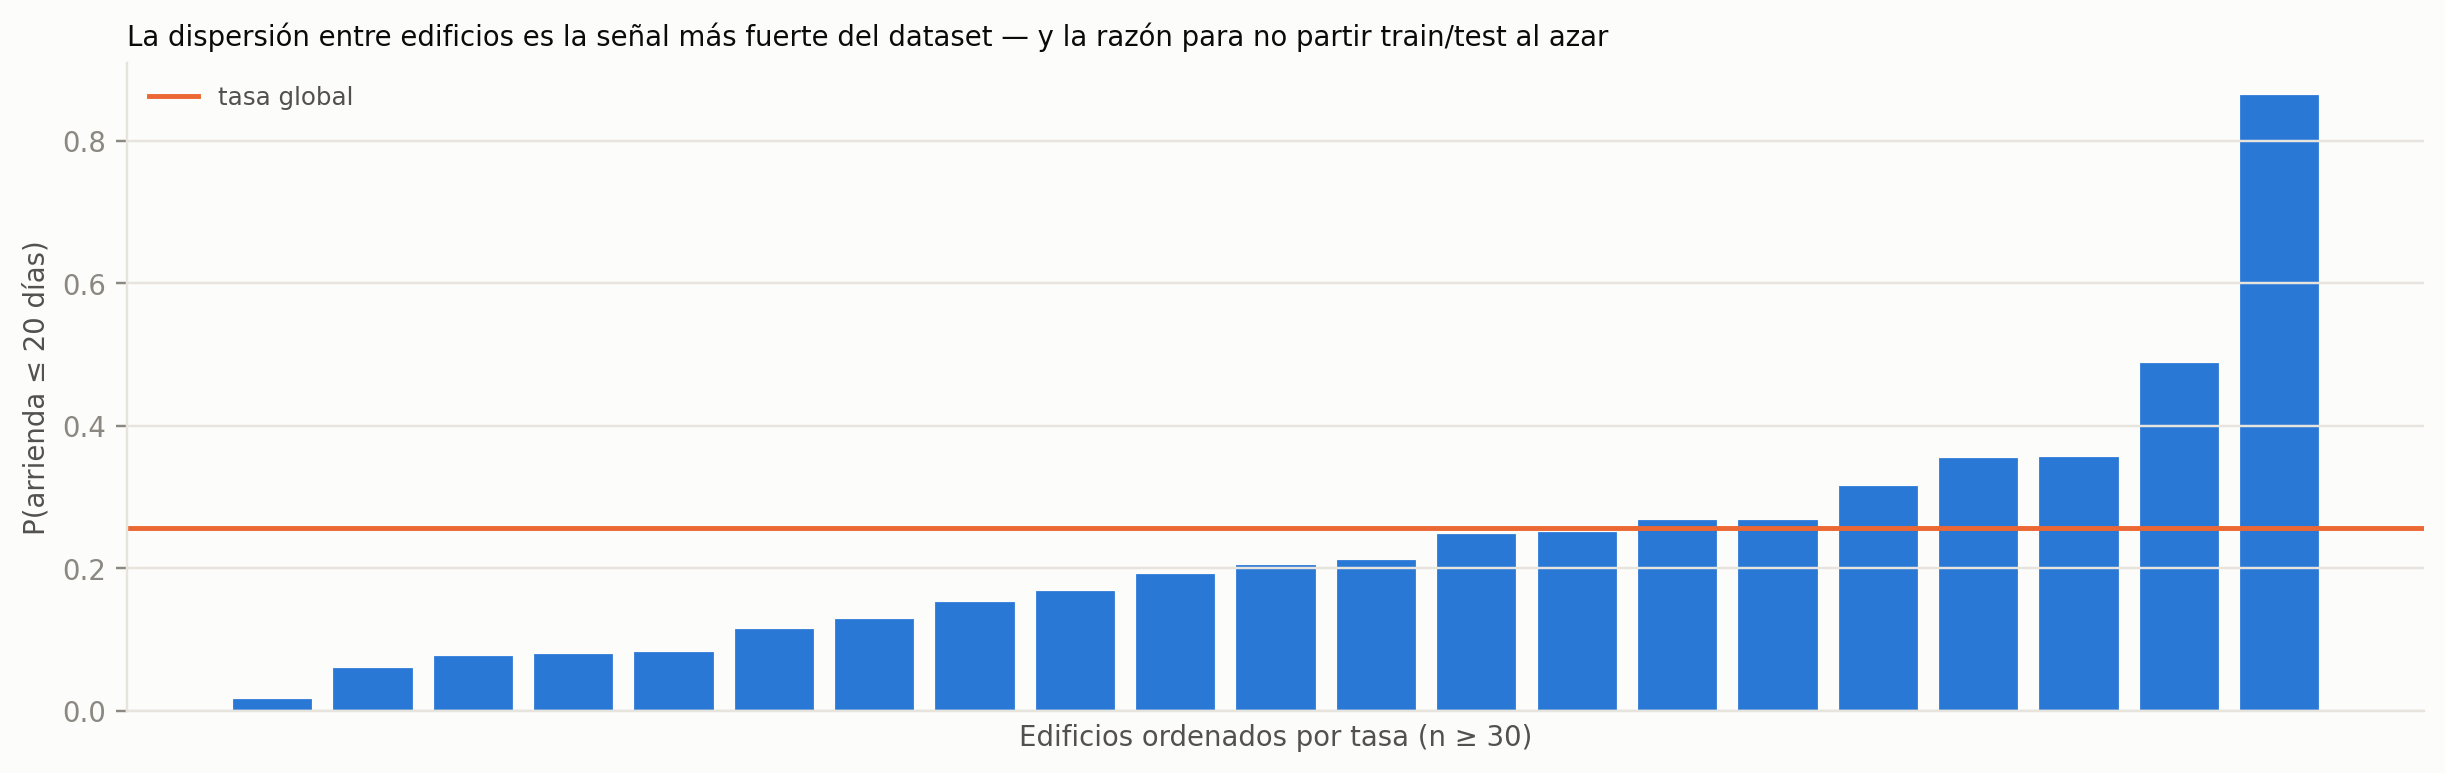

In [23]:
# grupo_edificio tiene cardinalidad alta y es la fuente natural de correlacion
# intra-grupo: dos unidades del mismo edificio comparten ubicacion, calidad y
# gestion, asi que sus desenlaces no son independientes. Eso importa para
# elegir el esquema de validacion mas adelante (agrupar por edificio, no
# partir al azar).
ed = (d.groupby("grupo_edificio")
        .agg(n=("property_id", "size"), y_20=("y_20", "mean"),
             churn=("no_modelo_churn", "mean"))
        .query(f"n >= {MIN_OBS}")
        .sort_values("y_20"))

print(f"Edificios con n >= {MIN_OBS}: {len(ed):,}  "
      f"(cubren {ed['n'].sum() / len(d):.0%} de la muestra)")
print(f"y_20 va de {ed['y_20'].min():.2f} a {ed['y_20'].max():.2f} entre edificios "
      f"(tasa global {d['y_20'].mean():.2f})")

fig, ax = plt.subplots(figsize=(11, 3.4), constrained_layout=True)
ax.bar(range(len(ed)), ed["y_20"], color=AZUL, edgecolor=SURFACE, linewidth=0.4)
ax.axhline(d["y_20"].mean(), color=NARANJA, lw=1.6, label="tasa global")
ax.set_xticks([]); ax.set_xlabel(f"Edificios ordenados por tasa (n ≥ {MIN_OBS})")
ax.set_ylabel("P(arrienda ≤ 20 días)")
ax.set_title("La dispersión entre edificios es la señal más fuerte del dataset — "
             "y la razón para no partir train/test al azar",
             fontsize=9, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=INK_SOFT)
plt.show()

## Paso 5 · Precio

El nivel de precio crudo contra días **no puede** mostrar el efecto de pricing: el nivel está
determinado por sector y tipología. Un departamento caro en Las Condes y uno barato en Estación
Central no compiten entre sí.

Lo que sí responde la pregunta es `log_ratio_centrado`: el gap contra la recomendación del ML,
centrado en su celda comuna × tipología × mes. El centrado absorbe dos cosas de una vez — la
deriva de mercado que introduce el snapshot ex-post del ML, y el confounding de segmento que
hacía ilegible el scatter original.

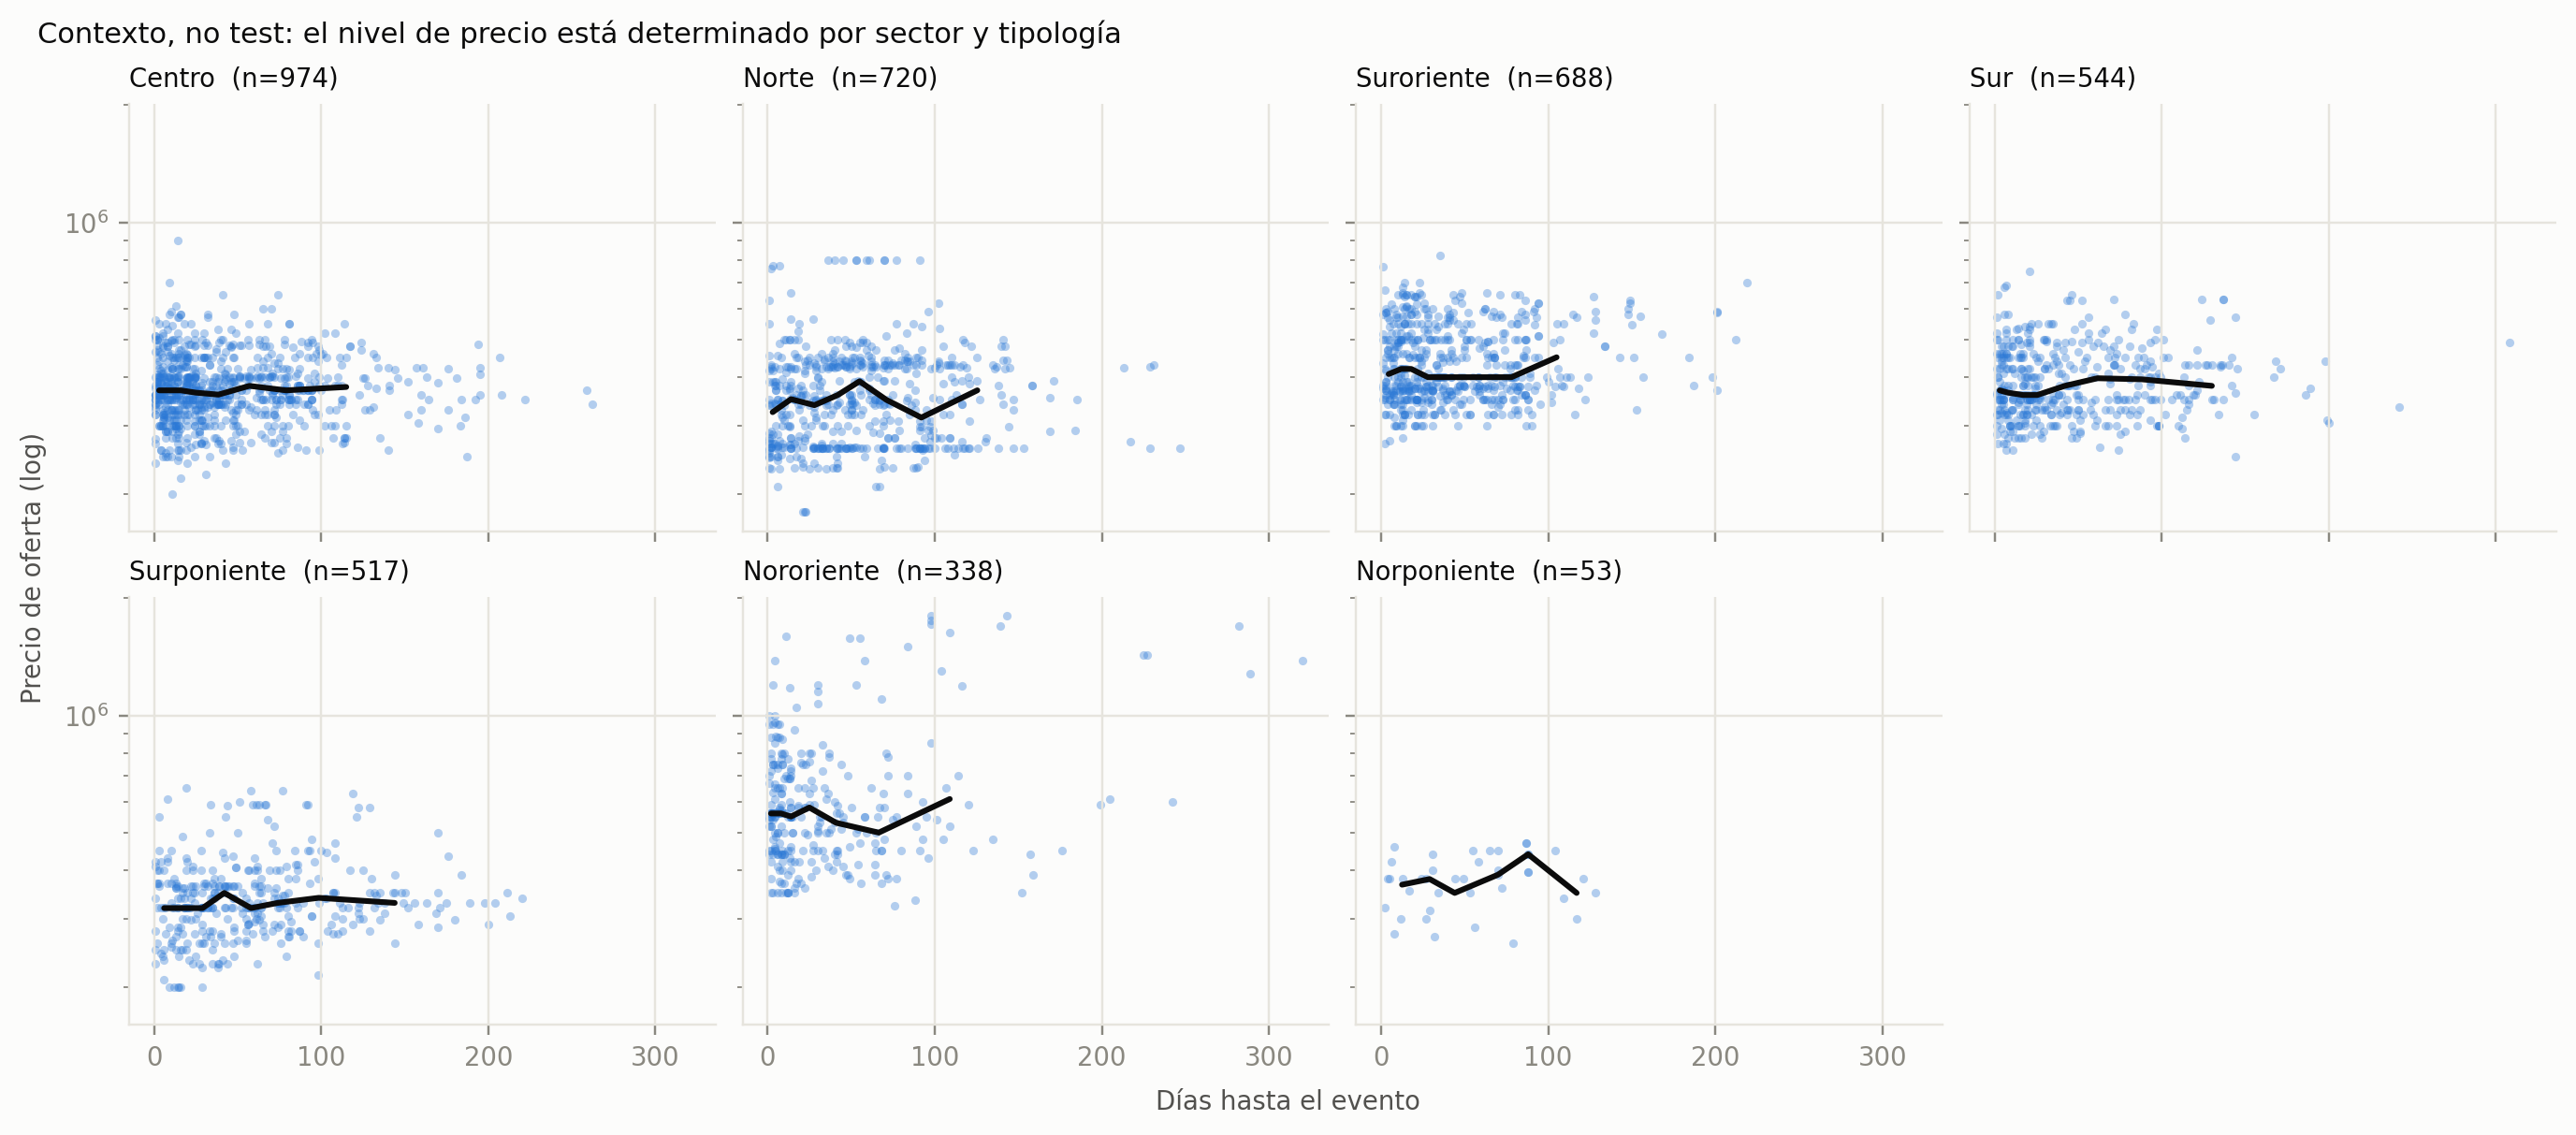

In [24]:
sectores = d["sector_provincia"].value_counts().index.tolist()
ncol = 4
nrow = int(np.ceil(len(sectores) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 2.7 * nrow),
                         sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax, sec in zip(axes, sectores):
    g = d[d["sector_provincia"] == sec]
    ax.scatter(g["no_modelo_days_to_event"], g["precio_oferta"], s=9, alpha=0.35,
               color=AZUL, linewidths=0)
    b = mediana_por_bin(g, "no_modelo_days_to_event", "precio_oferta", n_bins=8)
    if len(b):
        ax.plot(b["x"], b["p50"], color=INK, lw=2, solid_capstyle="round")
    ax.set_yscale("log")
    ax.set_title(f"{sec.replace('Santiago - ', '')}  (n={len(g):,})", fontsize=9, loc="left")
for ax in axes[len(sectores):]:
    ax.set_visible(False)

fig.supxlabel("Días hasta el evento", color=INK_SOFT, fontsize=9)
fig.supylabel("Precio de oferta (log)", color=INK_SOFT, fontsize=9)
fig.suptitle("Contexto, no test: el nivel de precio está determinado por sector y tipología",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

Muestra con gap legible: 2,354 de 3,834 (|gap| <= 0.5, n_segmento >= 5)


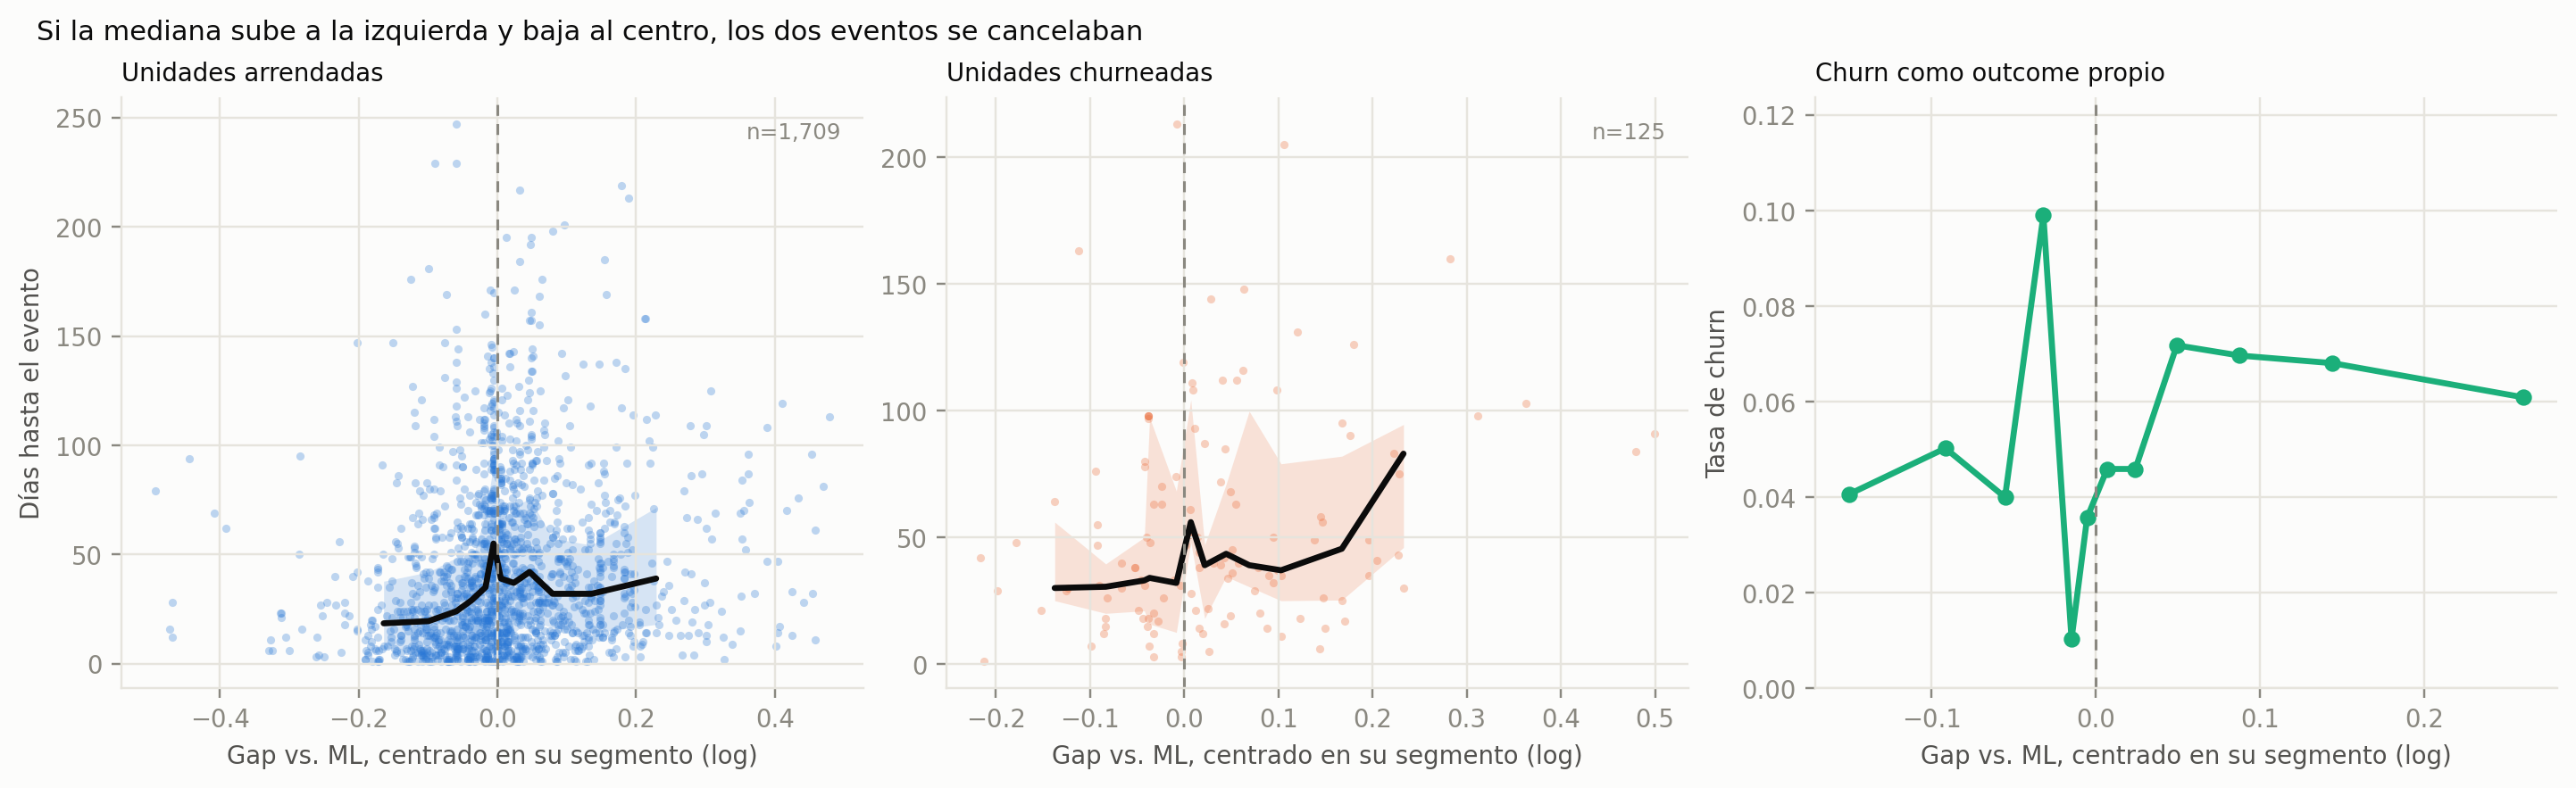

In [25]:
# El test. Tres paneles porque son tres preguntas distintas:
#   arrendadas -> el sobreprecio, ¿alarga la colocacion?
#   churneadas -> la misma pendiente aqui pero invertida es la cancelacion
#   churn      -> el sobreprecio, ¿no demora sino que mata?
GAP = "log_ratio_centrado"     # cambiar a "log_ratio_ml" para ver el gap sin centrar

g_all = d[d[GAP].notna() & d[GAP].abs().le(GAP_MAX) & d["n_segmento"].ge(N_SEG_MIN)]
print(f"Muestra con gap legible: {len(g_all):,} de {len(d):,} "
      f"(|gap| <= {GAP_MAX}, n_segmento >= {N_SEG_MIN})")



fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), constrained_layout=True)

for ax, (tipo, titulo, color) in zip(
    axes[:2], [("arriendo", "Unidades arrendadas", AZUL),
               ("churn",    "Unidades churneadas", NARANJA)]
):
    g = g_all[g_all["no_modelo_tipo_evento"] == tipo]
    ax.scatter(g[GAP], g["no_modelo_days_to_event"], s=9, alpha=0.30,
               color=color, linewidths=0)
    b = mediana_por_bin(g, GAP, "no_modelo_days_to_event")
    if len(b):
        ax.fill_between(b["x"], b["p25"], b["p75"], color=color, alpha=0.18, linewidth=0)
        ax.plot(b["x"], b["p50"], color=INK, lw=2.2, solid_capstyle="round")
        ax.annotate(f"n={int(b['n'].sum()):,}", xy=(0.97, 0.93), xycoords="axes fraction",
                    ha="right", color=INK_MUTED, fontsize=8)
    ax.axvline(0, color=INK_MUTED, lw=1, ls=(0, (4, 3)))
    ax.set_title(titulo, fontsize=9, loc="left")
    ax.set_xlabel("Gap vs. ML, centrado en su segmento (log)")
axes[0].set_ylabel("Días hasta el evento")

ax = axes[2]
tasa = (g_all.assign(_bin=pd.qcut(g_all[GAP], 12, duplicates="drop"))
             .groupby("_bin", observed=True)
             .agg(gap=(GAP, "median"), churn=("no_modelo_churn", "mean"),
                  n=("no_modelo_churn", "size"))
             .query("n >= 5"))
ax.plot(tasa["gap"], tasa["churn"], color=AQUA, lw=2.2, marker="o", ms=5,
        solid_capstyle="round")
ax.axvline(0, color=INK_MUTED, lw=1, ls=(0, (4, 3)))
ax.set_ylim(0, max(tasa["churn"].max() * 1.25, 0.02))
ax.set_xlabel("Gap vs. ML, centrado en su segmento (log)")
ax.set_ylabel("Tasa de churn")
ax.set_title("Churn como outcome propio", fontsize=9, loc="left")

fig.suptitle("Si la mediana sube a la izquierda y baja al centro, los dos eventos se cancelaban",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

In [26]:
# El mismo test en numeros, para pegar en un informe.
# dias_p50 solo entre arrendadas; tasa_churn sobre el total del decil.
tab = (g_all.assign(decil=lambda t: pd.qcut(t[GAP], 10, labels=False, duplicates="drop") + 1)
            .groupby("decil")
            .apply(lambda g: pd.Series({
                "n":            len(g),
                "gap_pct":      np.expm1(g[GAP].mean()),
                "n_arrendadas": (g["no_modelo_tipo_evento"] == "arriendo").sum(),
                "dias_p50":     g.loc[g["no_modelo_tipo_evento"] == "arriendo",
                                      "no_modelo_days_to_event"].median(),
                "dias_media":   g.loc[g["no_modelo_tipo_evento"] == "arriendo",
                                      "no_modelo_days_to_event"].mean(),
                "dias_se":      g.loc[g["no_modelo_tipo_evento"] == "arriendo",
                                      "no_modelo_days_to_event"].std()
                                / np.sqrt(max((g["no_modelo_tipo_evento"] == "arriendo").sum(), 1)),
                "y_20":         g["y_20"].mean(),
                "churn":        g["no_modelo_churn"].mean(),
                "visitas_2sem": g[["no_modelo_visitas_sem_1", "no_modelo_visitas_sem_2"]].sum(axis=1).mean(),
                "leads":        g["no_modelo_leads_90d"].mean(),
                "reservas":     g["no_modelo_reservas_90d"].mean(),
            }), include_groups=False)
            .round(3))
display(tab)

bajo, alto = tab.iloc[:2], tab.iloc[-2:]
d_bajo = np.average(bajo["dias_media"], weights=bajo["n_arrendadas"].clip(lower=1))
d_alto = np.average(alto["dias_media"], weights=alto["n_arrendadas"].clip(lower=1))
se = np.sqrt((bajo["dias_se"] ** 2).sum() + (alto["dias_se"] ** 2).sum())
print(f"\nDías a arriendo, deciles 1-2 (más baratos vs. su segmento) : {d_bajo:.1f}")
print(f"Días a arriendo, deciles 9-10 (más caros vs. su segmento)  : {d_alto:.1f}")
print(f"Diferencia: {d_alto - d_bajo:+.1f} días  (SE aprox {se:.1f}, "
      f"~{abs(d_alto - d_bajo) / se:.1f} errores estándar)")

,n,gap_pct,n_arrendadas,dias_p50,dias_media,dias_se,y_20,churn,visitas_2sem,leads,reservas
decil,,,,,,,,,,,
1,236.000,-0.153,189.000,19.000,28.339,2.213,0.432,0.038,18.572,8.055,0.767
2,235.000,-0.077,187.000,20.000,36.406,3.249,0.410,0.047,12.532,5.191,0.702
3,236.000,-0.043,165.000,28.000,33.115,2.189,0.289,0.089,14.169,6.530,0.699
4,237.000,-0.019,165.000,35.000,42.830,2.810,0.257,0.021,11.730,5.650,0.641
5,234.000,-0.005,179.000,49.000,56.268,2.907,0.174,0.034,9.235,4.667,0.615
6,236.000,0.009,161.000,38.000,44.075,2.712,0.228,0.051,7.953,3.953,0.674
7,235.000,0.032,166.000,40.000,48.753,3.110,0.196,0.055,9.566,4.387,0.596
8,234.000,0.068,174.000,36.500,50.006,3.309,0.226,0.056,9.863,3.799,0.628
9,235.000,0.131,166.000,33.500,42.036,2.800,0.243,0.068,11.723,5.409,0.681



Días a arriendo, deciles 1-2 (más baratos vs. su segmento) : 32.4
Días a arriendo, deciles 9-10 (más caros vs. su segmento)  : 45.6
Diferencia: +13.2 días  (SE aprox 5.8, ~2.3 errores estándar)


In [27]:
# Comportamiento de precio DENTRO de la ventana. Es post-LPA, asi que no es
# feature, pero dice si la casa reacciona cuando una unidad no se coloca.
comp_precio = (d.assign(bajo_precio=lambda t: t["no_modelo_pct_bajada"].gt(0.01))
                 .groupby("bajo_precio")
                 .agg(n=("property_id", "size"),
                      dias_p50=("no_modelo_days_to_event", "median"),
                      y_20=("y_20", "mean"),
                      churn=("no_modelo_churn", "mean"),
                      n_precios=("no_modelo_n_precios_ventana", "mean"),
                      pct_bajada_media=("no_modelo_pct_bajada", "mean")))
display(comp_precio.round(3))
print("Esto NO es causal en ninguna direccion: se baja el precio porque no se arrienda,\n"
      "y se demora porque estaba caro. Lo unico que la tabla establece es la frecuencia\n"
      "con que la casa interviene y el tamano tipico de esa intervencion.")

,n,dias_p50,y_20,churn,n_precios,pct_bajada_media
bajo_precio,,,,,,
False,2403,24.000,0.355,0.198,0.803,-0.010
True,1431,53.000,0.099,0.154,2.393,0.081


Esto NO es causal en ninguna direccion: se baja el precio porque no se arrienda,
y se demora porque estaba caro. Lo unico que la tabla establece es la frecuencia
con que la casa interviene y el tamano tipico de esa intervencion.


## Paso 6 · Demanda y la ventana landmark

El embudo `visitas → leads → reservas → contrato` es lo más informativo del dataset y también
lo más peligroso: se acumula **durante** la ventana de predicción. Una unidad que se arrendó
rápido tiene pocas visitas porque tuvo pocos días, no porque tuviera poca demanda. Usar los
totales como feature de un score del día 0 es fuga de información pura.

Todas las columnas de demanda están **acotadas a los primeros 90 días** de ventana (sufijo
`_90d`). Sin ese tope, una unidad que lleva año y medio buscando acumula visitas simplemente
por llevar más tiempo publicada, y el conteo termina midiendo el reloj en vez de la demanda.

La ventana `d0_7_` resuelve la otra mitad del problema: al día 7 esas visitas ya ocurrieron,
así que sirven para predecir los días 8 en adelante. Pero solo dentro de `sobrevive_d7 = 1`. En una unidad que se
colocó el día 3, el conteo de la ventana está truncado por el evento, y un número bajo significa
poco tiempo, no poca demanda.

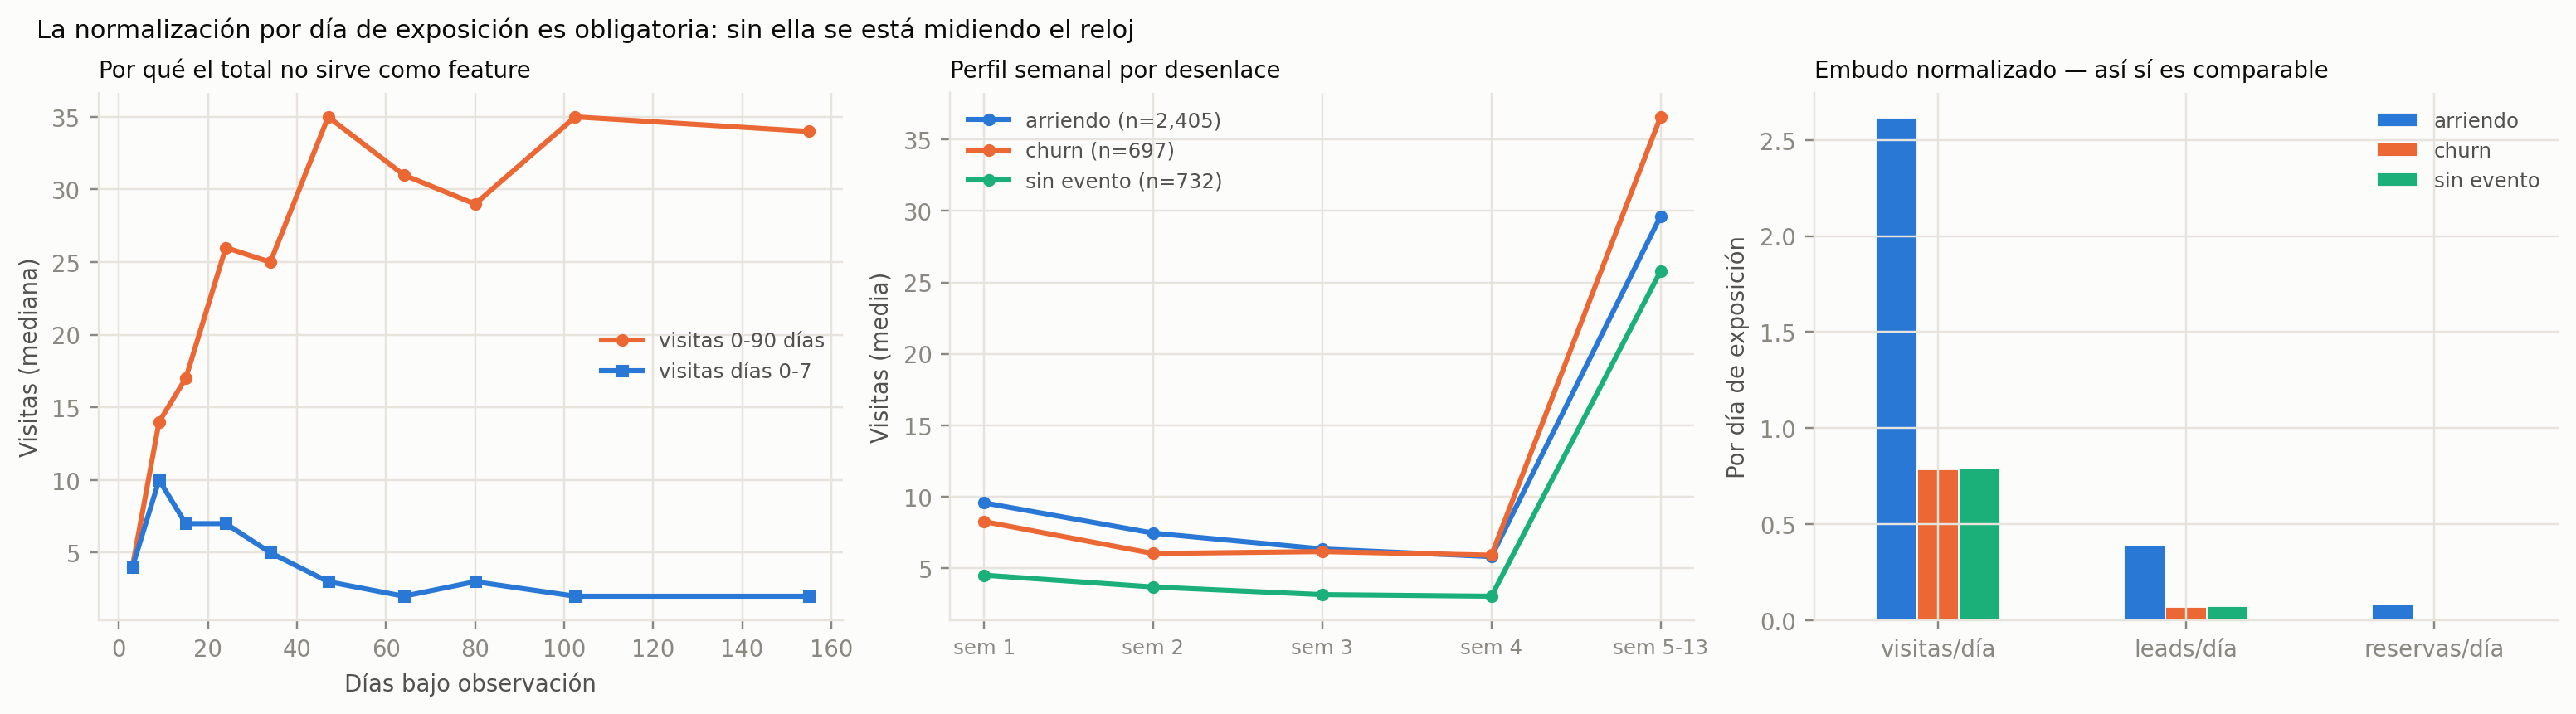

In [28]:
sem = ["no_modelo_visitas_sem_1", "no_modelo_visitas_sem_2",
       "no_modelo_visitas_sem_3", "no_modelo_visitas_sem_4",
       "no_modelo_visitas_sem5_a_90"]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

# --- 1. El sesgo de exposicion, explicito
ax = axes[0]
b_tot = mediana_por_bin(d, "no_modelo_dias_observados", "no_modelo_visitas_90d", n_bins=10)
b_d07 = mediana_por_bin(d, "no_modelo_dias_observados", "d0_7_visitas", n_bins=10)
ax.plot(b_tot["x"], b_tot["p50"], color=NARANJA, lw=2, marker="o", ms=4,
        label="visitas 0-90 días")
ax.plot(b_d07["x"], b_d07["p50"], color=AZUL, lw=2, marker="s", ms=4,
        label="visitas días 0-7")
ax.set_xlabel("Días bajo observación"); ax.set_ylabel("Visitas (mediana)")
ax.set_title("Por qué el total no sirve como feature", fontsize=9, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=INK_SOFT)

# --- 2. Perfil semanal de visitas por desenlace
ax = axes[1]
for tipo, color in [("arriendo", AZUL), ("churn", NARANJA), ("sin evento", AQUA)]:
    g = d[d["no_modelo_tipo_evento"] == tipo]
    if not len(g):
        continue
    ax.plot(range(1, 6), g[sem].mean().values, color=color, lw=2, marker="o", ms=4,
            label=f"{tipo} (n={len(g):,})")
ax.set_xticks(range(1, 6))
ax.set_xticklabels(["sem 1", "sem 2", "sem 3", "sem 4", "sem 5-13"], fontsize=8)
ax.set_ylabel("Visitas (media)")
ax.set_title("Perfil semanal por desenlace", fontsize=9, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=INK_SOFT)

# --- 3. Embudo, normalizado por dia de exposicion
ax = axes[2]
den = d["no_modelo_dias_observados"].clip(lower=1)
emb = pd.DataFrame({
    "visitas/día":  d["no_modelo_visitas_90d"] / den,
    "leads/día":    d["no_modelo_leads_90d"] / den,
    "reservas/día": d["no_modelo_reservas_90d"] / den,
    "tipo": d["no_modelo_tipo_evento"],
})
piv = emb.groupby("tipo").mean()
piv.T.plot(kind="bar", ax=ax, color=[AZUL, NARANJA, AQUA], edgecolor=SURFACE, linewidth=0.6,
           legend=True, rot=0)
ax.set_ylabel("Por día de exposición")
ax.set_title("Embudo normalizado — así sí es comparable", fontsize=9, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=INK_SOFT, title=None)

fig.suptitle("La normalización por día de exposición es obligatoria: sin ella se está midiendo el reloj",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

In [29]:
# La ventana landmark, en la submuestra donde es interpretable.
lm = d[d["sobrevive_d7"] == 1].copy()
print(f"Sobreviven al día 7: {len(lm):,} de {len(d):,} ({len(lm)/len(d):.1%})")

# Target condicional: entre las que llegaron vivas al dia 7, ¿arriendan
# antes del dia 20? Es la pregunta que la ventana d0-7 puede responder sin fuga.
arrendo_8_20 = ((lm["no_modelo_tipo_evento"] == "arriendo")
                & lm["no_modelo_days_to_event"].between(7, 20))
observable   = (lm["no_modelo_dias_observados"] >= 20) | (lm["no_modelo_days_to_event"] <= 20)
lm["y_8a20"] = np.where(observable, arrendo_8_20.astype(float), np.nan)

print(f"Tasa base y_8a20 = {lm['y_8a20'].mean():.3f} "
      f"(sobre {int(lm['y_8a20'].notna().sum()):,} filas observables)")

filas = []
for c in ["d0_7_visitas", "d0_7_leads", "d0_7_reservas"]:
    p = perfil_por_bin(lm, c, n_bins=5, y="y_8a20")
    if len(p):
        p.insert(0, "variable", c)
        filas.append(p.reset_index())
if filas:
    display(pd.concat(filas).round(3).to_string(index=False))

Sobreviven al día 7: 3,412 de 3,834 (89.0%)
Tasa base y_8a20 = 0.170 (sobre 3,258 filas observables)


' _bin     variable         n  x_p50  y_8a20  n_arrendadas  dias_p50  dias_media  dias_se  churn  censurada\n    0 d0_7_visitas 1,425.000  0.000   0.100       802.000    49.000      58.332    1.446  0.154      0.283\n    1 d0_7_visitas   725.000  4.000   0.142       407.000    38.000      47.528    1.749  0.226      0.212\n    2 d0_7_visitas   626.000  9.000   0.196       365.000    29.000      40.726    1.697  0.243      0.174\n    3 d0_7_visitas   636.000 20.000   0.336       440.000    22.000      32.543    1.394  0.204      0.104\n    0   d0_7_leads 2,813.000  0.000   0.124     1,589.000    42.000      51.897    0.959  0.199      0.236\n    1   d0_7_leads   599.000  3.000   0.388       425.000    19.000      30.226    1.372  0.179      0.112'

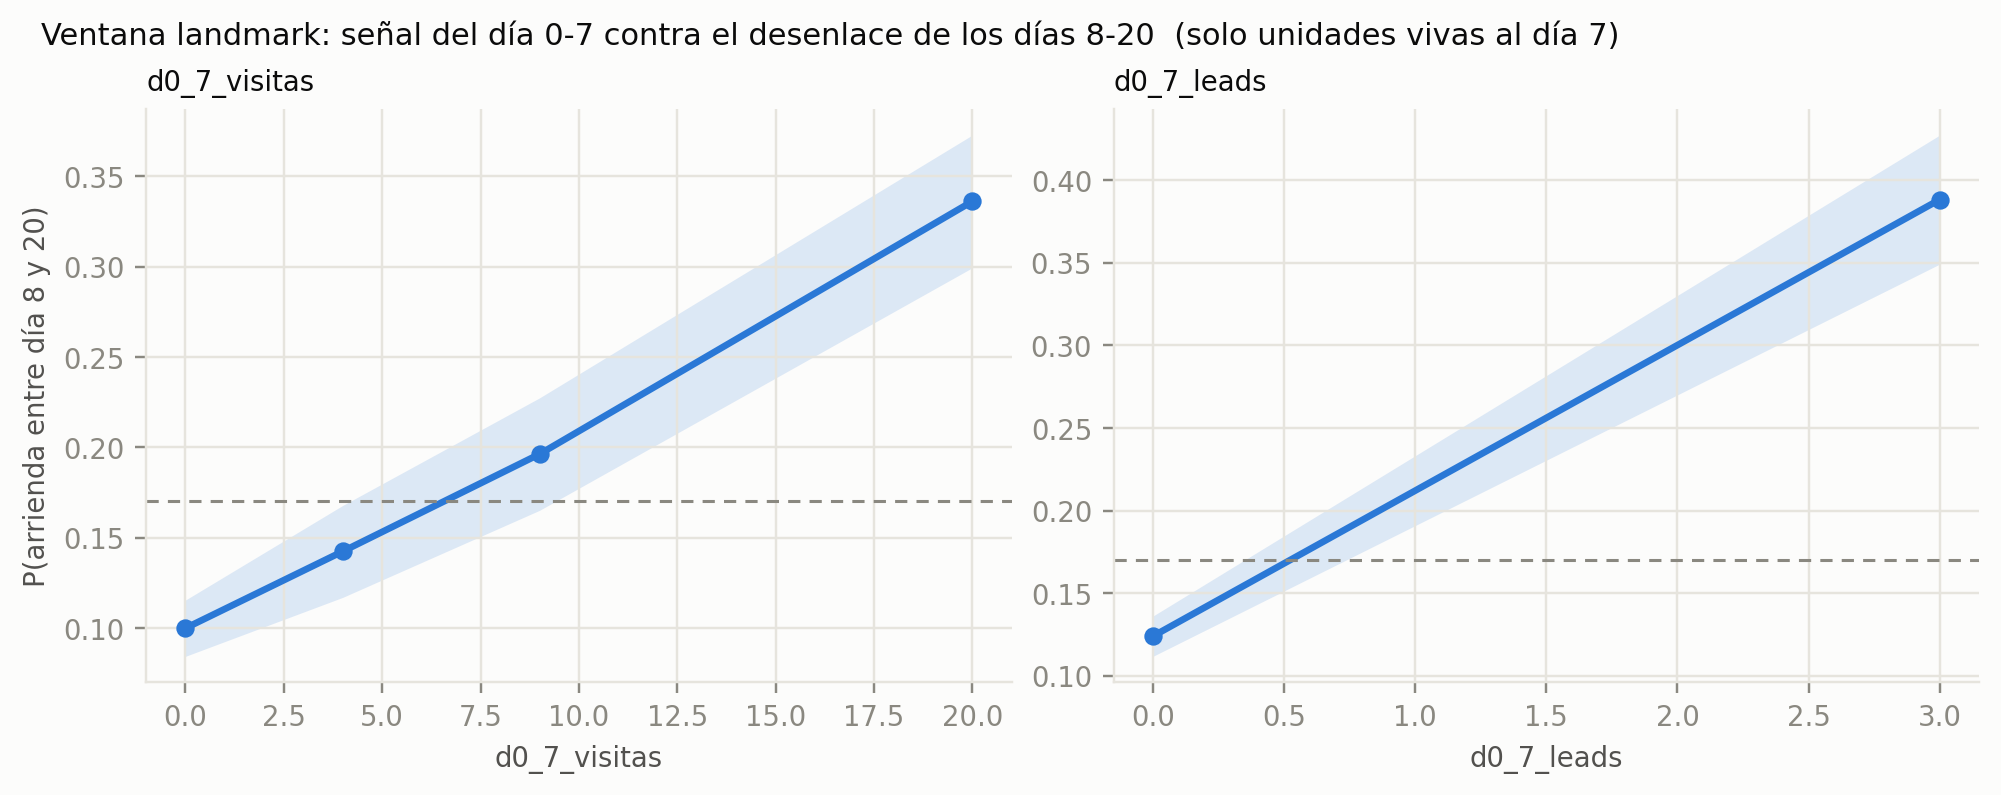

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
for ax, c in zip(axes, ["d0_7_visitas", "d0_7_leads", "d0_7_reservas"]):
    p = perfil_por_bin(lm, c, n_bins=5, y="y_8a20")
    if not len(p):
        ax.set_visible(False); continue
    ax.plot(p["x_p50"], p["y_8a20"], color=AZUL, lw=2.2, marker="o", ms=5)
    ax.fill_between(p["x_p50"],
                    p["y_8a20"] - 1.96 * np.sqrt(p["y_8a20"] * (1 - p["y_8a20"]) / p["n"]),
                    p["y_8a20"] + 1.96 * np.sqrt(p["y_8a20"] * (1 - p["y_8a20"]) / p["n"]),
                    color=AZUL, alpha=0.15, linewidth=0)
    ax.axhline(lm["y_8a20"].mean(), color=INK_MUTED, lw=1, ls=(0, (4, 3)))
    ax.set_xlabel(c); ax.set_title(c, fontsize=9, loc="left")
axes[0].set_ylabel("P(arrienda entre día 8 y 20)")
fig.suptitle("Ventana landmark: señal del día 0-7 contra el desenlace de los días 8-20  "
             "(solo unidades vivas al día 7)",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

## Paso 7 · Deriva temporal

Dos preguntas distintas. **¿El mercado cambió?** Si la tasa de colocación se mueve entre
cohortes por razones de mercado (estacionalidad, desempleo, competencia), un modelo entrenado en
enero no sirve en octubre y hay que partir train/test **por tiempo**, nunca al azar.

**¿O es artefacto de censura?** Las cohortes recientes llevan menos días observados. Si la caída
en la tasa coincide con la subida de `censurada`, no hay deriva: hay inmadurez, y la solución es
recortar la muestra, no re-entrenar.

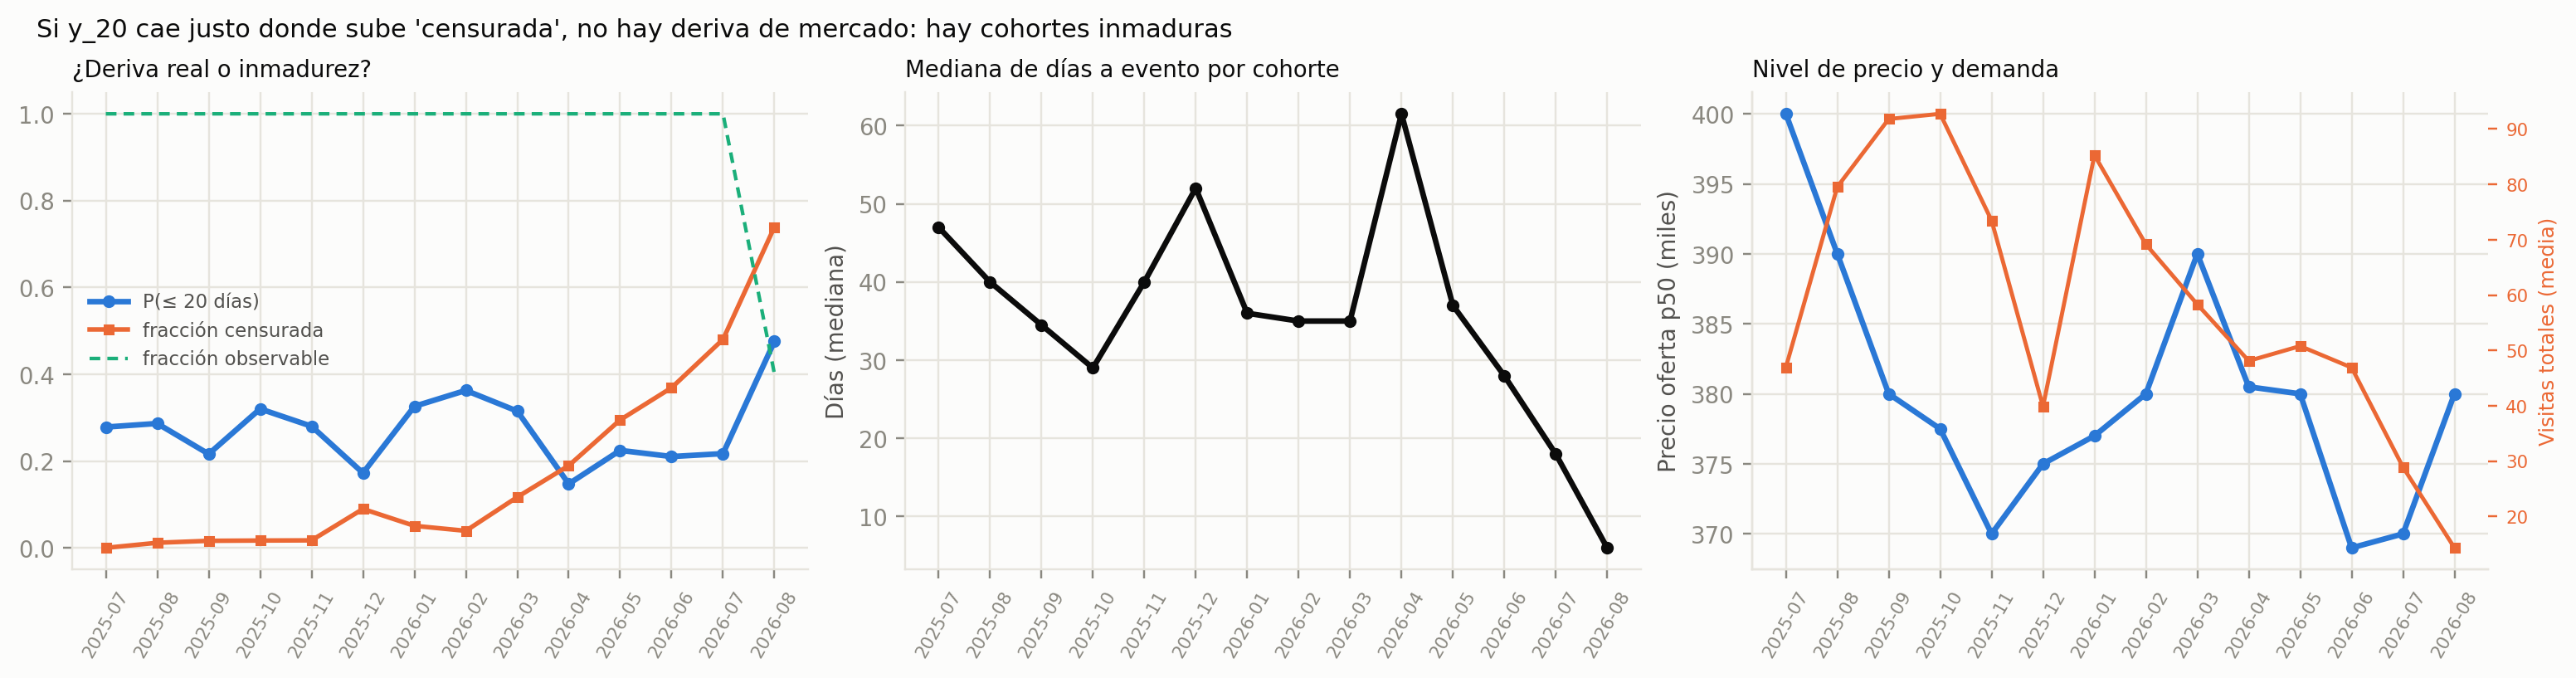

,n,y_20,y_20_obs,censurada,churn,dias_p50,precio_p50,visitas_dia,gap_medio
cohorte_lpa,,,,,,,,,
2025-07,97,0.278,1.000,0.000,0.299,47.000,"400,000.000",46.948,0.033
2025-08,171,0.287,1.000,0.012,0.287,40.000,"390,000.000",79.550,0.006
2025-09,185,0.216,1.000,0.016,0.346,34.500,"380,000.000",91.811,0.004
2025-10,178,0.320,1.000,0.017,0.219,29.000,"377,500.000",92.747,0.012
2025-11,232,0.280,1.000,0.017,0.198,40.000,"370,000.000",73.474,0.035
2025-12,435,0.172,1.000,0.090,0.110,52.000,"375,000.000",39.860,-0.024
2026-01,276,0.326,1.000,0.051,0.203,36.000,"377,000.000",85.286,-0.002
2026-02,306,0.363,1.000,0.039,0.193,35.000,"380,000.000",69.167,-0.000
2026-03,419,0.315,1.000,0.117,0.158,35.000,"390,000.000",58.320,0.039


In [31]:
coh = (d.groupby("cohorte_lpa")
         .agg(n              = ("property_id", "size"),
              y_20           = ("y_20", "mean"),
              y_20_obs       = ("y_20", lambda s: s.notna().mean()),
              censurada      = ("no_modelo_censurada", "mean"),
              churn          = ("no_modelo_churn", "mean"),
              dias_p50       = ("no_modelo_days_to_event", "median"),
              precio_p50     = ("precio_oferta", "median"),
              visitas_dia    = ("no_modelo_visitas_90d", "mean"),
              gap_medio      = ("log_ratio_ml", "mean")))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
x = range(len(coh))

ax = axes[0]
ax.plot(x, coh["y_20"], color=AZUL, lw=2.2, marker="o", ms=4, label="P(≤ 20 días)")
ax.plot(x, coh["censurada"], color=NARANJA, lw=1.8, marker="s", ms=3, label="fracción censurada")
ax.plot(x, coh["y_20_obs"], color=AQUA, lw=1.4, ls=(0, (3, 2)), label="fracción observable")
ax.set_xticks(list(x)); ax.set_xticklabels(coh.index, rotation=60, fontsize=7)
ax.set_title("¿Deriva real o inmadurez?", fontsize=9, loc="left")
ax.legend(frameon=False, fontsize=7.5, labelcolor=INK_SOFT)

ax = axes[1]
ax.plot(x, coh["dias_p50"], color=INK, lw=2.2, marker="o", ms=4)
ax.set_xticks(list(x)); ax.set_xticklabels(coh.index, rotation=60, fontsize=7)
ax.set_ylabel("Días (mediana)")
ax.set_title("Mediana de días a evento por cohorte", fontsize=9, loc="left")

ax = axes[2]
ax.plot(x, coh["precio_p50"] / 1000, color=AZUL, lw=2.2, marker="o", ms=4)
ax.set_xticks(list(x)); ax.set_xticklabels(coh.index, rotation=60, fontsize=7)
ax.set_ylabel("Precio oferta p50 (miles)")
ax2 = ax.twinx()
ax2.plot(x, coh["visitas_dia"], color=NARANJA, lw=1.6, marker="s", ms=3)
ax2.set_ylabel("Visitas totales (media)", color=NARANJA, fontsize=8)
ax2.grid(False); ax2.tick_params(colors=NARANJA, labelsize=7)
ax.set_title("Nivel de precio y demanda", fontsize=9, loc="left")

fig.suptitle("Si y_20 cae justo donde sube 'censurada', no hay deriva de mercado: hay cohortes inmaduras",
             fontsize=10, color=INK, x=0.01, ha="left")
plt.show()

display(coh.round(3))

## Paso 8 · Colinealidad

No para descartar variables — con regularización dos variables correlacionadas no rompen la
predicción — sino para **no leer dos veces el mismo efecto**. `precio_oferta`, `precio_m2` y
`m2_utiles` son aritméticamente la misma información vista de tres formas; si las tres aparecen
"significativas", eso es un artefacto, no tres hallazgos.

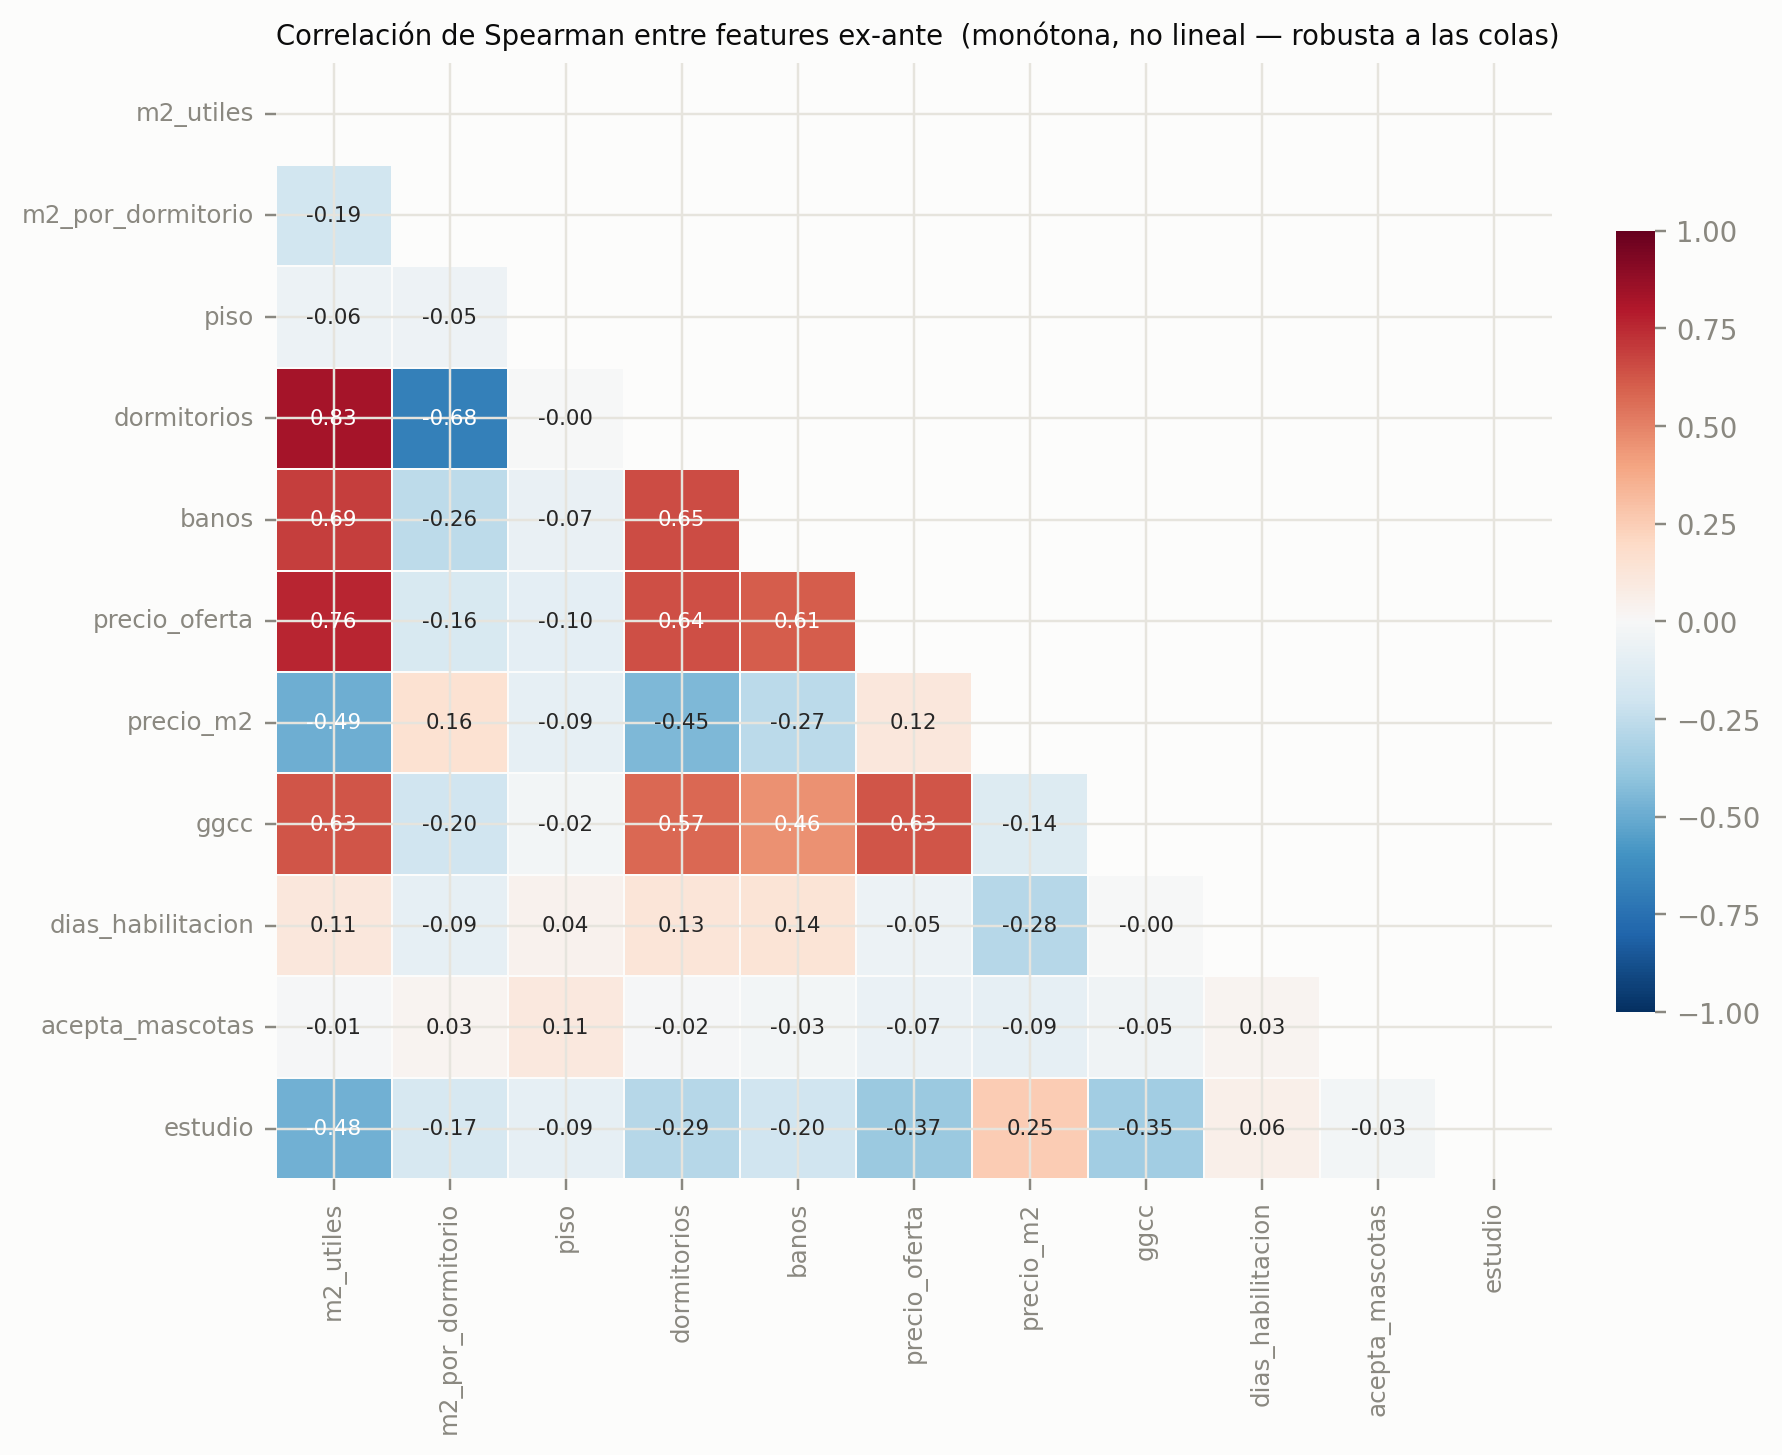


Pares con |rho| >= 0,6 — son la misma información, elegir uno:


,a,b,rho
3,dormitorios,m2_utiles,0.830
10,precio_oferta,m2_utiles,0.763
6,banos,m2_utiles,0.689
4,dormitorios,m2_por_dormitorio,-0.684
9,banos,dormitorios,0.652
13,precio_oferta,dormitorios,0.643
26,ggcc,precio_oferta,0.627
21,ggcc,m2_utiles,0.625
14,precio_oferta,banos,0.605


In [32]:
corr_vars = [c for c in FEATURES_NUM if d[c].notna().sum() > len(d) * 0.5]
corr = d[corr_vars].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5), constrained_layout=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.6, linecolor=SURFACE, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlación de Spearman entre features ex-ante  "
             "(monótona, no lineal — robusta a las colas)",
             fontsize=9, loc="left", color=INK)
ax.tick_params(labelsize=8)
plt.show()

altas = (corr.where(~mask).stack()
             .rename("rho").reset_index()
             .rename(columns={"level_0": "a", "level_1": "b"}))
altas = altas[altas["rho"].abs() >= 0.6].sort_values("rho", key=abs, ascending=False)
print("\nPares con |rho| >= 0,6 — son la misma información, elegir uno:")
display(altas.round(3))

## Cómo leer el conjunto

| Lo que ves | Lo que significa |
|---|---|
| Un motivo de exclusión pesado y con churn distinto | El análisis está condicionado en el éxito. Es la primera limitación del informe, no una nota al pie |
| Pico grande en la primera semana | `fecha_LPA` retroalimentada. Hay que resolverlo antes de interpretar cualquier duración |
| `censurada` alto en las cohortes recientes | No hay deriva de mercado, hay inmadurez. Recortar la muestra, no re-entrenar |
| `sd(log_ratio_ml)` bajo 0,05 | El ML aprendió la política de precios de la casa, no el mercado. No hay varianza que correlacionar y el problema está en su target de entrenamiento |
| Gradiente en arrendadas, invertido en churn | Los dos eventos se cancelaban dentro de `days_to_event`. La correlación existía |
| Gradiente **solo** en la tasa de churn | El sobreprecio no alarga la colocación: la mata. La unidad no espera más, sale del inventario. Hallazgo distinto y comercialmente más relevante |
| Deciles centrales planos, extremos que se mueven | Efecto de umbral. Usar dummies por tramo, nunca una pendiente lineal |
| Visitas planas entre deciles de precio | La señal de precio no está llegando al mercado. Revisar publicación en portales y promociones no registradas |
| Dispersión de `y_20` grande entre edificios | El edificio explica más que cualquier feature de la unidad. La partición train/test tiene que agrupar por edificio |

**Una advertencia que no se arregla con más datos.** Si el precio se fija a partir de la
recomendación del ML, las desviaciones no son ruido aleatorio: son información privada del
equipo comercial sobre esa unidad — vista, ruido, terminaciones. El gap entonces mide en parte
calidad no observada por el modelo, y eso empuja la correlación hacia cero. Nada de lo que hay
en este notebook lo resuelve; se necesita variación exógena, tipo un A/B de precios. Lo que sale
de acá es **asociación**, y conviene presentarlo como tal.

## Hallazgos

_Completar después de la primera corrida. Una línea por hallazgo, con el número al lado._

| # | Hallazgo | Evidencia (paso / tabla) | Qué implica para el modelo |
|---|---|---|---|
| 1 |  |  |  |
| 2 |  |  |  |
| 3 |  |  |  |

**Decisiones que este análisis debe dejar cerradas antes de escribir la primera línea de modelo:**

1. Qué target — binario a 20 días, o duración con censura.
2. Qué muestra — qué motivos de exclusión se aceptan y cuál es el sesgo declarado.
3. Qué features ex-ante entran, y cuáles se descartan por colinealidad.
4. Si se usa la ventana landmark, y con qué target condicional.
5. Cómo se parte train/test — por tiempo, agrupando por edificio, o ambas.